<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/TRACK_D_Stage_1__SELF_SUPERVISED_CROSS_MODAL_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

┌─────────────────────────────────────────────────────────────┐
│              TRACK D: CROSS-MODAL CONTRASTIVE ViT          │
└─────────────────────────────────────────────────────────────┘

                    ┌──────────────────┐
                    │  16,691 Samples  │
                    └────────┬─────────┘
                             │
              ┌──────────────┼──────────────┐
              │              │              │
         ┌────▼────┐    ┌───▼────┐    ┌───▼────┐
         │ S1 (4ch)│    │ S2 (6ch│    │L1B Wave│
         │ 32×32   │    │ 32×32  │    │ (384)  │
         └────┬────┘    └───┬────┘    └───┬────┘
              │             │              │
    ┌─────────▼─────────────▼──────────────▼─────────┐
    │      CROSS-MODAL FUSION TRANSFORMER             │
    │   (All modalities attend to each other)         │
    └─────────┬───────────────────────────────────────┘
              │
    ┌─────────▼─────────┐
    │  Unified Embedding│  [8+1 modalities, 64 tokens, 96 dims]
    │   (Modalities +   │
    │    Waveform)      │
    └─────────┬─────────┘
              │
    ┌─────────▼─────────┐
    │ CONTRASTIVE LOSS  │
    │ • Same location   │
    │ • Cross-modal     │
    │ • Temporal        │
    └───────────────────┘

         PRE-TRAINING (16,691 samples)
                  ↓
         FINE-TUNING (942 samples)
                  ↓
            Stage 2 (RF/MLP)
                  ↓
         RH / PAI / FHD Predictions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Pre Flight

In [ ]:
import os
import re
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/data/chips/processed_32x32_normalized"

# Get first 20 filenames
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')][:20]

print("="*70)
print("SAMPLE FILENAMES FROM YOUR DIRECTORY")
print("="*70)

for i, filename in enumerate(tif_files, 1):
    print(f"{i:2d}. {filename}")

# Test pattern
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)

print("\n" + "="*70)
print("PATTERN MATCHING TEST")
print("="*70)

matched = 0
not_matched = 0

for filename in tif_files:
    match = pattern.match(filename)
    if match:
        matched += 1
        print(f"✓ MATCH: {filename}")
        print(f"  → {match.groupdict()}")
    else:
        not_matched += 1
        print(f"✗ NO MATCH: {filename}")

print(f"\n📊 Summary:")
print(f"  Matched: {matched}/{len(tif_files)}")
print(f"  Not matched: {not_matched}/{len(tif_files)}")

SAMPLE FILENAMES FROM YOUR DIRECTORY
 1. s2_train_GEDI_L2B_2020196021509_2103_block_5963898.tif
 2. s2idx_test_GEDI_L2B_2020196021509_2716_block_5933898.tif
 3. landsatidx_test_GEDI_L2B_2021135083748_2683_block_6033892.tif
 4. landsatidx_test_GEDI_L2B_2021135083748_1875_block_5933898.tif
 5. landsatidx_train_GEDI_L2B_2021135083748_2187_block_5993893.tif
 6. s1_train_GEDI_L2B_2021135083748_2648_block_5993895.tif
 7. s1_train_GEDI_L2B_2021135083748_1943_block_5993893.tif
 8. s1_train_GEDI_L2B_2020196021509_2103_block_5963898.tif
 9. s2idx_train_GEDI_L2B_2021135083748_2401_block_5993895.tif
10. s1_test_GEDI_L2B_2021135083748_2695_block_6033892.tif
11. s2_test_GEDI_L2B_2022139064237_2567_block_5923889.tif
12. s2idx_train_GEDI_L2B_2021135083748_2185_block_5993893.tif
13. landsatidx_train_GEDI_L2B_2020196021509_2282_block_5943897.tif
14. s1_train_GEDI_L2B_2020196021509_2020_block_5923895.tif
15. s1_test_GEDI_L2B_2021135083748_1876_block_5933898.tif
16. s1_train_GEDI_L2B_2021135083748_2440_bl

In [ ]:
# # =====================================================
# # TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
# # WITH L1B AS 9TH MODALITY + LAT/LON TRACKING
# # =====================================================

# import os
# import sys
# import re
# import pickle
# import shutil
# from collections import defaultdict
# from datetime import datetime

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# from torch.optim.lr_scheduler import CosineAnnealingLR

# import rasterio
# from sklearn.model_selection import train_test_split

# print("="*70)
# print("TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING")
# print("9 Modalities: 8 Images + L1B Waveforms + Lat/Lon Tracking")
# print("="*70)

# # =====================================================
# # 1. CONFIGURATION
# # =====================================================

# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
# RASTER_DIR = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/data/chips/processed_32x32_normalized")
# L1B_FILE = os.path.join(BASE_DIR, "GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy")
# LABELS_CSV = os.path.join("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid_multitask.csv")


# #################GEDI Filter module
# # Load labels CSV
# labels_df = pd.read_csv(LABELS_CSV)
# print(f"✓ Loaded {len(labels_df)} rows")

# # CRITICAL: FILTER BAD DATA
# print("\nFiltering data quality...")
# original_count = len(labels_df)

# # Remove invalid RH values
# labels_df = labels_df[
#     (labels_df['rh'] >= 0) &      # No negative heights
#     (labels_df['rh'] <= 50) &     # Reasonable maximum
#     (~labels_df['rh'].isna())     # No NaN
# ]
# print(f"  After RH filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

# # # Remove low quality GEDI shots
# # if 'quality_flag' in labels_df.columns:
# #     labels_df = labels_df[labels_df['quality_flag'] == 1]
# #     print(f"  After quality filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

# # if 'sensitivity' in labels_df.columns:
# #     labels_df = labels_df[labels_df['sensitivity'] > 0.9]
# #     print(f"  After sensitivity filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

# # Remove extreme PAI/FHD values
# if 'pai' in labels_df.columns:
#     labels_df = labels_df[
#         (labels_df['pai'] >= 0) &
#         (labels_df['pai'] <= 10) &
#         (~labels_df['pai'].isna())
#     ]
#     print(f"  After PAI filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

# if 'fhd_normal' in labels_df.columns:
#     labels_df = labels_df[
#         (labels_df['fhd_normal'] >= 0) &
#         (labels_df['fhd_normal'] <= 5) &
#         (~labels_df['fhd_normal'].isna())
#     ]
#     print(f"  After FHD filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

# print(f"✓ Kept {len(labels_df)}/{original_count} rows ({100*len(labels_df)/original_count:.1f}%) after filtering")






# TRACK_D_DIR = os.path.join(BASE_DIR, "Track_D_Contrastive")
# CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
# RESULTS_DIR = os.path.join(TRACK_D_DIR, "results")

# os.makedirs(TRACK_D_DIR, exist_ok=True)
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# os.makedirs(RESULTS_DIR, exist_ok=True)

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# EMBED_DIM = 96
# PATCH_SIZE = 4
# IMG_SIZE = 32
# NUM_CROSS_MODAL_BLOCKS = 4
# NUM_MODALITY_BLOCKS = 2
# BATCH_SIZE = 32
# LEARNING_RATE = 1e-4
# PRETRAIN_EPOCHS = 100
# TEMPERATURE = 0.07
# TRAIN_RATIO = 0.70
# TEST_RATIO = 0.20
# VAL_RATIO = 0.10

# print(f"✓ Device: {DEVICE}")
# print(f"✓ Epochs: {PRETRAIN_EPOCHS}")

# # =====================================================
# # 2. PRE-FLIGHT CHECKS
# # =====================================================

# print("\n" + "="*70)
# print("PRE-FLIGHT CHECKS")
# print("="*70)

# if not os.path.exists(RASTER_DIR):
#     print(f"✗ RASTER_DIR not found")
#     sys.exit(1)

# tif_count = len([f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')])
# print(f"✓ Raster directory: {tif_count} TIF files")

# # Load L1B waveforms as 9th modality
# l1b_waveforms_array = None
# if os.path.exists(L1B_FILE):
#     try:
#         l1b_raw = np.load(L1B_FILE, allow_pickle=True)

#         if isinstance(l1b_raw, np.ndarray) and l1b_raw.shape == ():
#             l1b_raw = l1b_raw.item()

#         if isinstance(l1b_raw, dict):
#             l1b_waveforms_list = []

#             if 'rxwaveform' in l1b_raw:
#                 for waveform in l1b_raw['rxwaveform']:
#                     if waveform is not None:
#                         wf = np.array(waveform, dtype=np.float32)
#                         if len(wf) < 384:
#                             wf = np.pad(wf, (0, 384 - len(wf)))
#                         elif len(wf) > 384:
#                             wf = wf[:384]
#                         l1b_waveforms_list.append(wf)

#             if len(l1b_waveforms_list) > 0:
#                 l1b_waveforms_array = np.array(l1b_waveforms_list)
#                 print(f"✓ L1B waveforms: {l1b_waveforms_array.shape[0]} samples (9th modality)")
#             else:
#                 print(f"⚠️  Could not extract waveforms from L1B")
#         else:
#             print(f"⚠️  L1B format not recognized")

#     except Exception as e:
#         print(f"⚠️  Error loading L1B: {e}")
# else:
#     print(f"⚠️  L1B file not found")

# # Load labels CSV to get lat/lon coordinates
# print("\n" + "="*70)
# print("LOADING LAT/LON FROM LABELS CSV")
# print("="*70)

# if os.path.exists(LABELS_CSV):
#     labels_df = pd.read_csv(LABELS_CSV)
#     print(f"✓ Loaded {len(labels_df)} rows from labels CSV")

#     # Create mapping: filename → (lat, lon, rh, pai, fhd)
#     filename_to_metadata = {}
#     for idx, row in labels_df.iterrows():
#         filename = row['filename']
#         filename_to_metadata[filename] = {
#             'lat': row['lat'],
#             'lon': row['lon'],
#             'rh': row.get('rh', np.nan),
#             'pai': row.get('pai', np.nan),
#             'fhd': row.get('fhd_normal', np.nan),
#             'shot_number': row['shot']
#         }

#     print(f"✓ Created metadata lookup for {len(filename_to_metadata)} filenames")
# else:
#     print(f"✗ Labels CSV not found: {LABELS_CSV}")
#     sys.exit(1)

# print("✅ Pre-flight complete\n")

# # =====================================================
# # 3. DATA INDEXING
# # =====================================================

# print("="*70)
# print("INDEXING MULTIMODAL SAMPLES")
# print("="*70)

# EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']

# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8, 'landsat': 6,
#     'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
# }

# pattern = re.compile(
#     r"(?P<covariate>.*?)_(?P<split>train|test|val)_(?P<product_field>GEDI_[A-Z0-9]+)_"
#     r"(?P<shot>[0-9]+)_(?P<row_id>[0-9]+)_block_(?P<block_id>[0-9]+)\.tif$"
# )

# shot_groups = defaultdict(lambda: {
#     'modalities': {}, 'metadata': {}, 'original_split': None, 'product_field': None,
#     'lat': None, 'lon': None, 'rh': None, 'pai': None, 'fhd': None
# })

# tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')]

# for filename in tqdm(tif_files, desc="Indexing"):
#     match = pattern.match(filename)
#     if match:
#         covariate = match.group("covariate")
#         product_field = match.group("product_field")

#         if product_field in ["GEDI_L2A", "GEDI_L2B"] and covariate in EO_LIST:
#             sample_key = f"{match.group('shot')}_{match.group('row_id')}_{product_field}"
#             filepath = os.path.join(RASTER_DIR, filename)

#             shot_groups[sample_key]['modalities'][covariate] = filepath
#             shot_groups[sample_key]['original_split'] = match.group("split")
#             shot_groups[sample_key]['product_field'] = product_field
#             shot_groups[sample_key]['metadata'] = {
#                 'shot_number': match.group("shot"),
#                 'row_id': match.group("row_id"),
#                 'original_split': match.group("split"),
#                 'product_field': product_field,
#                 'block_id': match.group("block_id")
#             }

#             # Add lat/lon from labels CSV
#             if filename in filename_to_metadata:
#                 meta = filename_to_metadata[filename]
#                 shot_groups[sample_key]['lat'] = meta['lat']
#                 shot_groups[sample_key]['lon'] = meta['lon']
#                 shot_groups[sample_key]['rh'] = meta['rh']
#                 shot_groups[sample_key]['pai'] = meta['pai']
#                 shot_groups[sample_key]['fhd'] = meta['fhd']

# complete_samples = []
# for sample_key, data in shot_groups.items():
#     if len(data['modalities']) == len(EO_LIST):
#         if all(mod in data['modalities'] for mod in EO_LIST):
#             complete_samples.append({
#                 'shot_id': sample_key,
#                 'modalities': data['modalities'],
#                 'metadata': data['metadata'],
#                 'original_split': data['original_split'],
#                 'product_field': data['product_field'],
#                 'lat': data['lat'],
#                 'lon': data['lon'],
#                 'rh': data['rh'],
#                 'pai': data['pai'],
#                 'fhd': data['fhd']
#             })

# print(f"✓ Found {len(complete_samples)} complete samples")

# # Count samples with coordinates
# samples_with_coords = sum(1 for s in complete_samples if s['lat'] is not None)
# print(f"✓ {samples_with_coords}/{len(complete_samples)} samples have lat/lon ({100*samples_with_coords/len(complete_samples):.1f}%)")

# if len(complete_samples) < 10:
#     print("✗ Need at least 10 samples")
#     sys.exit(1)

# # =====================================================
# # 3b. SPLIT BY UNIQUE FOOTPRINTS (NOT CHIPS)
# # =====================================================

# print("\n" + "="*70)
# print("SPLITTING BY UNIQUE GEDI FOOTPRINTS")
# print("="*70)

# # Create unique footprint identifiers (shot + lat + lon)
# footprint_to_samples = defaultdict(list)
# for sample in complete_samples:
#     if sample['lat'] is not None and sample['lon'] is not None:
#         # Round lat/lon to avoid floating point issues
#         footprint_key = f"{sample['metadata']['shot_number']}_{round(sample['lat'], 6)}_{round(sample['lon'], 6)}"
#         footprint_to_samples[footprint_key].append(sample)

# unique_footprints = list(footprint_to_samples.keys())
# print(f"✓ Found {len(unique_footprints)} unique GEDI footprints")

# if len(unique_footprints) < 10:
#     print(f"✗ Only {len(unique_footprints)} unique footprints - need at least 10")
#     sys.exit(1)

# # Split by footprint, not by chip
# train_footprints, temp_footprints = train_test_split(unique_footprints, test_size=0.3, random_state=42)
# test_footprints, val_footprints = train_test_split(temp_footprints, test_size=0.333, random_state=42)

# # Collect all samples for each split
# train_samples = []
# for fp in train_footprints:
#     train_samples.extend(footprint_to_samples[fp])

# test_samples = []
# for fp in test_footprints:
#     test_samples.extend(footprint_to_samples[fp])

# val_samples = []
# for fp in val_footprints:
#     val_samples.extend(footprint_to_samples[fp])


# print(f"\n✓ Split by footprints:")
# print(f"  Train: {len(train_footprints)} footprints → {len(train_samples)} samples")
# print(f"  Test:  {len(test_footprints)} footprints → {len(test_samples)} samples")
# print(f"  Val:   {len(val_footprints)} footprints → {len(val_samples)} samples")

# # Verify no overlap
# train_fps_set = set(train_footprints)
# test_fps_set = set(test_footprints)
# val_fps_set = set(val_footprints)

# assert len(train_fps_set & test_fps_set) == 0, "Train/Test footprint overlap!"
# assert len(train_fps_set & val_fps_set) == 0, "Train/Val footprint overlap!"
# assert len(test_fps_set & val_fps_set) == 0, "Test/Val footprint overlap!"
# print("✓ No overlap between splits")



# # =====================================================
# # 4. COPY TO LOCAL STORAGE
# # =====================================================

# print("\n" + "="*70)
# print("COPYING TO LOCAL STORAGE")
# print("="*70)

# LOCAL_CACHE_DIR = "/content/track_d_cache"
# os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)

# files_to_copy = set()
# for sample in complete_samples:
#     for filepath in sample['modalities'].values():
#         files_to_copy.add(filepath)

# local_file_mapping = {}
# for src_path in tqdm(files_to_copy, desc="Copying"):
#     filename = os.path.basename(src_path)
#     dst_path = os.path.join(LOCAL_CACHE_DIR, filename)
#     if not os.path.exists(dst_path):
#         shutil.copy2(src_path, dst_path)
#     local_file_mapping[src_path] = dst_path

# for sample in complete_samples:
#     for modality in sample['modalities']:
#         sample['modalities'][modality] = local_file_mapping[sample['modalities'][modality]]

# print(f"✓ Cached locally")

# # =====================================================
# # 5. LOAD INTO MEMORY
# # =====================================================

# print("\n" + "="*70)
# print("LOADING INTO MEMORY")
# print("="*70)

# def load_sample_into_memory(sample):
#     modality_images = {}
#     for modality in EO_LIST:
#         with rasterio.open(sample['modalities'][modality]) as src:
#             modality_images[modality] = src.read().astype(np.float32)

#     return {
#         'shot_id': sample['shot_id'],
#         'modality_images': modality_images,
#         'metadata': sample['metadata'],
#         'lat': sample['lat'],
#         'lon': sample['lon'],
#         'rh': sample['rh'],
#         'pai': sample['pai'],
#         'fhd': sample['fhd']
#     }

# train_data_memory = [load_sample_into_memory(s) for s in tqdm(train_samples, desc="Train")]
# test_data_memory = [load_sample_into_memory(s) for s in tqdm(test_samples, desc="Test")]
# val_data_memory = [load_sample_into_memory(s) for s in tqdm(val_samples, desc="Val")]

# print(f"✓ Loaded: Train={len(train_data_memory)}, Test={len(test_data_memory)}, Val={len(val_data_memory)}")

# # Verify labels are present
# train_with_labels = sum(1 for s in train_data_memory if not np.isnan(s['rh']))
# test_with_labels = sum(1 for s in test_data_memory if not np.isnan(s['rh']))
# print(f"✓ Samples with RH labels: Train={train_with_labels}/{len(train_data_memory)}, Test={test_with_labels}/{len(test_data_memory)}")

# # =====================================================
# # 6. MODEL ARCHITECTURES
# # =====================================================

# print("\n" + "="*70)
# print("DEFINING MODEL")
# print("="*70)

# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=96, img_size=32):
#         super().__init__()
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         return self.proj(x).flatten(2).transpose(1, 2)

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=96, num_heads=4, mlp_ratio=4., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self, x):
#         x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
#         x = x + self.mlp(self.norm2(x))
#         return x

# class CrossModalAttention(nn.Module):
#     def __init__(self, embed_dim=96, num_heads=8, dropout=0.1):
#         super().__init__()
#         self.norm = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
#         self.mlp = nn.Sequential(
#             nn.LayerNorm(embed_dim),
#             nn.Linear(embed_dim, embed_dim * 4),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(embed_dim * 4, embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self, x):
#         x = x + self.attn(self.norm(x), self.norm(x), self.norm(x))[0]
#         return x + self.mlp(x)

# class MultiModalViT_Contrastive(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.embed_dim = 96
#         self.tokens_per_modality = 64

#         self.patch_embeds = nn.ModuleDict({
#             mod: PatchEmbed(BANDS_PER_COV[mod], 4, 96, 32) for mod in EO_LIST
#         })

#         self.l1b_encoder = nn.Sequential(
#             nn.Linear(384, 512), nn.GELU(), nn.Dropout(0.1),
#             nn.Linear(512, 64 * 96)
#         )

#         self.modality_type_embed = nn.Parameter(torch.randn(9, 96))
#         self.pos_embed = nn.Parameter(torch.randn(64, 96))

#         self.cross_modal_blocks = nn.ModuleList([CrossModalAttention(96) for _ in range(4)])
#         self.modality_encoders = nn.ModuleDict({
#             mod: nn.ModuleList([TransformerBlock(96) for _ in range(2)]) for mod in EO_LIST
#         })

#         self.projection_head = nn.Sequential(nn.Linear(96, 96), nn.GELU(), nn.Linear(96, 128))

#         nn.init.trunc_normal_(self.modality_type_embed, std=0.02)
#         nn.init.trunc_normal_(self.pos_embed, std=0.02)

#     def forward(self, modality_images, l1b_batch=None):
#         B = list(modality_images.values())[0].size(0)

#         tokens = {}
#         for i, mod in enumerate(EO_LIST):
#             t = self.patch_embeds[mod](modality_images[mod])
#             t = t + self.pos_embed.unsqueeze(0) + self.modality_type_embed[i].unsqueeze(0).unsqueeze(0)
#             tokens[mod] = t

#         if l1b_batch is not None:
#             l1b_flat = self.l1b_encoder(l1b_batch)
#             l1b_tokens = l1b_flat.view(B, 64, 96)
#             l1b_tokens = l1b_tokens + self.pos_embed.unsqueeze(0) + self.modality_type_embed[8].unsqueeze(0).unsqueeze(0)
#             tokens['l1b'] = l1b_tokens

#         modality_list = EO_LIST + (['l1b'] if l1b_batch is not None else [])
#         all_tokens = torch.cat([tokens[m] for m in modality_list], dim=1)

#         for block in self.cross_modal_blocks:
#             all_tokens = block(all_tokens)

#         fused_tokens = {}
#         for i, mod in enumerate(EO_LIST):
#             start, end = i * 64, (i + 1) * 64
#             mod_tokens = all_tokens[:, start:end, :]
#             for block in self.modality_encoders[mod]:
#                 mod_tokens = block(mod_tokens)
#             fused_tokens[mod] = mod_tokens

#         if l1b_batch is not None:
#             fused_tokens['l1b'] = all_tokens[:, len(EO_LIST)*64:, :]

#         stacked = torch.stack([fused_tokens[m] for m in EO_LIST], dim=1)
#         pooled = all_tokens.mean(dim=1)
#         projected = self.projection_head(pooled)

#         return {
#             'modality_tokens': stacked,
#             'pooled_embedding': pooled,
#             'projected_embedding': projected,
#             'per_modality_embeddings': fused_tokens
#         }

# class MultiModalContrastiveLoss(nn.Module):
#     def __init__(self, temperature=0.07):
#         super().__init__()
#         self.temperature = temperature

#     def info_nce_loss(self, anchor, positive, negatives):
#         anchor = F.normalize(anchor, dim=1)
#         positive = F.normalize(positive, dim=1)
#         negatives = F.normalize(negatives, dim=2)
#         pos_sim = torch.sum(anchor * positive, dim=1) / self.temperature
#         neg_sim = torch.bmm(negatives, anchor.unsqueeze(2)).squeeze(2) / self.temperature
#         logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
#         labels = torch.zeros(anchor.size(0), dtype=torch.long, device=anchor.device)
#         return F.cross_entropy(logits, labels)

#     def forward(self, embeddings_list):
#         B = len(embeddings_list)
#         device = embeddings_list[0]['pooled_embedding'].device

#         s1_emb = torch.cat([e['per_modality_embeddings']['s1'].mean(dim=1) for e in embeddings_list])
#         s2_emb = torch.cat([e['per_modality_embeddings']['s2'].mean(dim=1) for e in embeddings_list])

#         losses = []
#         for i in range(B):
#             neg_idx = [j for j in range(B) if j != i]
#             if neg_idx:
#                 loss = self.info_nce_loss(s1_emb[i:i+1], s2_emb[i:i+1], s2_emb[neg_idx].unsqueeze(0))
#                 losses.append(loss)

#         l1b_loss = torch.tensor(0.0, device=device)
#         if 'l1b' in embeddings_list[0]['per_modality_embeddings']:
#             l1b_emb = torch.cat([e['per_modality_embeddings']['l1b'].mean(dim=1) for e in embeddings_list])
#             img_emb = torch.cat([e['pooled_embedding'] for e in embeddings_list])

#             l1b_losses = []
#             for i in range(B):
#                 neg_idx = [j for j in range(B) if j != i]
#                 if neg_idx:
#                     loss = self.info_nce_loss(img_emb[i:i+1], l1b_emb[i:i+1], l1b_emb[neg_idx].unsqueeze(0))
#                     l1b_losses.append(loss)

#             if l1b_losses:
#                 l1b_loss = torch.stack(l1b_losses).mean()

#         cross_modal = torch.stack(losses).mean() if losses else torch.tensor(0.0, device=device)
#         total = cross_modal + 0.5 * l1b_loss

#         return total, {'cross_modal': cross_modal.item(), 'waveform': l1b_loss.item()}

# print("✓ Model defined")

# # =====================================================
# # 7. CREATE DATALOADERS
# # =====================================================

# class InMemoryDataset(Dataset):
#     def __init__(self, data_list, l1b_array):
#         self.data = data_list
#         self.l1b_array = l1b_array

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         modality_images = {mod: torch.tensor(img, dtype=torch.float32) for mod, img in sample['modality_images'].items()}

#         l1b = None
#         if self.l1b_array is not None:
#             l1b_idx = np.random.randint(0, len(self.l1b_array))
#             l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)

#         return {
#             'modality_images': modality_images,
#             'l1b': l1b,
#             'shot_id': sample['shot_id'],
#             'lat': sample['lat'],
#             'lon': sample['lon'],
#             'rh': sample['rh'],
#             'pai': sample['pai'],
#             'fhd': sample['fhd']
#         }

# def collate_fn(batch):
#     modality_images = defaultdict(list)
#     l1bs = []
#     shot_ids = []
#     lats = []
#     lons = []
#     rhs = []
#     pais = []
#     fhds = []

#     for item in batch:
#         for mod, img in item['modality_images'].items():
#             modality_images[mod].append(img)
#         l1bs.append(item['l1b'])
#         shot_ids.append(item['shot_id'])
#         lats.append(item['lat'])
#         lons.append(item['lon'])
#         rhs.append(item['rh'])
#         pais.append(item['pai'])
#         fhds.append(item['fhd'])

#     stacked = {mod: torch.stack(imgs) for mod, imgs in modality_images.items()}
#     l1b_stacked = torch.stack(l1bs) if all(l is not None for l in l1bs) else None

#     return {
#         'modality_images': stacked,
#         'l1bs': l1b_stacked,
#         'shot_ids': shot_ids,
#         'lats': lats,
#         'lons': lons,
#         'rhs': rhs,
#         'pais': pais,
#         'fhds': fhds
#     }

# train_dataset = InMemoryDataset(train_data_memory, l1b_waveforms_array)
# test_dataset = InMemoryDataset(test_data_memory, l1b_waveforms_array)
# val_dataset = InMemoryDataset(val_data_memory, l1b_waveforms_array)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

# print(f"✓ Dataloaders ready:")
# print(f"  Train: {len(train_loader)} batches")
# print(f"  Test:  {len(test_loader)} batches")
# print(f"  Val:   {len(val_loader)} batches")

# model = MultiModalViT_Contrastive().to(DEVICE)
# criterion = MultiModalContrastiveLoss(TEMPERATURE)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
# scheduler = CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS, eta_min=1e-6)

# print(f"✓ Model ready: {sum(p.numel() for p in model.parameters()):,} parameters")
# print("\n💡 Ready to train!")

TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
9 Modalities: 8 Images + L1B Waveforms + Lat/Lon Tracking
✓ Loaded 9860 rows

Filtering data quality...
  After RH filter: 9634 rows (97.7%)
  After PAI filter: 9634 rows (97.7%)
  After FHD filter: 9634 rows (97.7%)
✓ Kept 9634/9860 rows (97.7%) after filtering
✓ Device: cuda
✓ Epochs: 100

PRE-FLIGHT CHECKS
✓ Raster directory: 12845 TIF files
✓ L1B waveforms: 3846 samples (9th modality)

LOADING LAT/LON FROM LABELS CSV
✓ Loaded 9860 rows from labels CSV
✓ Created metadata lookup for 9860 filenames
✅ Pre-flight complete

INDEXING MULTIMODAL SAMPLES


Indexing: 100%|██████████| 12845/12845 [00:00<00:00, 93683.91it/s]

✓ Found 1379 complete samples
✓ 1057/1379 samples have lat/lon (76.6%)

SPLITTING BY UNIQUE GEDI FOOTPRINTS
✓ Found 816 unique GEDI footprints

📊 Label distributions after filtering:


NameError: name 'footprint_labels' is not defined

In [ ]:
#2/6

# =====================================================
# TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
# WITH L1B MATCHED VIA ROW_ID + OFFSET CORRECTION
# =====================================================

import os
import sys
import re
import pickle
import shutil
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import rasterio
from sklearn.model_selection import train_test_split

print("="*70)
print("TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING")
print("9 Modalities: 8 Images + L1B (matched via row_ID + offset)")
print("="*70)

# =====================================================
# 1. CONFIGURATION
# =====================================================

BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
RASTER_DIR = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/data/chips/processed_32x32_normalized")
L1B_FILE = os.path.join(BASE_DIR, "GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy")
L1B_METADATA_CSV = os.path.join(BASE_DIR, "GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv")
LABELS_CSV = os.path.join(BASE_DIR, "Multi_Task_Implementation/df_valid_multitask.csv")

# ROW_ID OFFSET for L1B matching
L1B_ROW_ID_OFFSET = 638  # Discovered via diagnostic

# Load and filter labels
labels_df = pd.read_csv(LABELS_CSV)
print(f"✓ Loaded {len(labels_df)} rows from df_valid_multitask.csv")

print("\nFiltering data quality...")
original_count = len(labels_df)

labels_df = labels_df[
    (labels_df['rh'] >= 0) &
    (labels_df['rh'] <= 50) &
    (~labels_df['rh'].isna())
]
print(f"  After RH filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

if 'pai' in labels_df.columns:
    labels_df = labels_df[
        (labels_df['pai'] >= 0) &
        (labels_df['pai'] <= 10) &
        (~labels_df['pai'].isna())
    ]
    print(f"  After PAI filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

if 'fhd_normal' in labels_df.columns:
    labels_df = labels_df[
        (labels_df['fhd_normal'] >= 0) &
        (labels_df['fhd_normal'] <= 5) &
        (~labels_df['fhd_normal'].isna())
    ]
    print(f"  After FHD filter: {len(labels_df)} rows ({100*len(labels_df)/original_count:.1f}%)")

print(f"✓ Kept {len(labels_df)}/{original_count} rows ({100*len(labels_df)/original_count:.1f}%) after filtering")

TRACK_D_DIR = os.path.join(BASE_DIR, "Track_D_Contrastive")
CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
RESULTS_DIR = os.path.join(TRACK_D_DIR, "results")

os.makedirs(TRACK_D_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMBED_DIM = 96
PATCH_SIZE = 4
IMG_SIZE = 32
NUM_CROSS_MODAL_BLOCKS = 4
NUM_MODALITY_BLOCKS = 2
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
PRETRAIN_EPOCHS = 100
TEMPERATURE = 0.07

print(f"✓ Device: {DEVICE}")
print(f"✓ Epochs: {PRETRAIN_EPOCHS}")
print(f"✓ L1B row_ID offset: {L1B_ROW_ID_OFFSET}")

# =====================================================
# 2. LOAD L1B WITH ROW_ID MATCHING
# =====================================================

print("\n" + "="*70)
print("LOADING L1B WAVEFORMS (MATCHED VIA ROW_ID)")
print("="*70)

l1b_waveforms_array = None
l1b_rowid_to_idx = {}

# Load L1B metadata CSV to get row_ID mapping
if os.path.exists(L1B_METADATA_CSV):
    l1b_metadata_df = pd.read_csv(L1B_METADATA_CSV, low_memory=False)

    # Filter for L1B only
    l1b_only = l1b_metadata_df[l1b_metadata_df['product_field'] == 'GEDI_L1B'].copy()
    print(f"✓ Found {len(l1b_only)} L1B entries in metadata CSV")

    if len(l1b_only) > 0:
        # Create row_ID to index mapping
        l1b_rowid_list = l1b_only['row_ID'].tolist()

        # Load waveforms from NPY
        if os.path.exists(L1B_FILE):
            try:
                l1b_raw = np.load(L1B_FILE, allow_pickle=True)

                if isinstance(l1b_raw, np.ndarray) and l1b_raw.shape == ():
                    l1b_raw = l1b_raw.item()

                if isinstance(l1b_raw, dict) and 'rxwaveform' in l1b_raw:
                    l1b_waveforms_list = []
                    valid_row_ids = []

                    for i, waveform in enumerate(l1b_raw['rxwaveform']):
                        if waveform is not None and i < len(l1b_rowid_list):
                            wf = np.array(waveform, dtype=np.float32)
                            if len(wf) < 384:
                                wf = np.pad(wf, (0, 384 - len(wf)))
                            elif len(wf) > 384:
                                wf = wf[:384]

                            l1b_waveforms_list.append(wf)
                            valid_row_ids.append(l1b_rowid_list[i])

                    if len(l1b_waveforms_list) > 0:
                        l1b_waveforms_array = np.array(l1b_waveforms_list)

                        # Create row_ID → waveform index lookup
                        for idx, row_id in enumerate(valid_row_ids):
                            l1b_rowid_to_idx[row_id] = idx

                        print(f"✓ Loaded {l1b_waveforms_array.shape[0]} L1B waveforms")
                        print(f"✓ Created row_ID lookup: {len(l1b_rowid_to_idx)} mappings")
                        print(f"  Row_ID range: [{min(l1b_rowid_to_idx.keys())}, {max(l1b_rowid_to_idx.keys())}]")
                    else:
                        print("⚠️  No valid waveforms extracted")
                else:
                    print("⚠️  L1B NPY missing 'rxwaveform' field")

            except Exception as e:
                print(f"⚠️  Error loading L1B NPY: {e}")
                import traceback
                traceback.print_exc()
        else:
            print(f"⚠️  L1B NPY file not found: {L1B_FILE}")
    else:
        print("⚠️  No GEDI_L1B entries found in metadata CSV")
else:
    print(f"⚠️  L1B metadata CSV not found: {L1B_METADATA_CSV}")

print("✅ L1B loading complete\n")

# =====================================================
# 3. PRE-FLIGHT CHECKS
# =====================================================

print("="*70)
print("PRE-FLIGHT CHECKS")
print("="*70)

if not os.path.exists(RASTER_DIR):
    print(f"✗ RASTER_DIR not found")
    sys.exit(1)

tif_count = len([f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')])
print(f"✓ Raster directory: {tif_count} TIF files")

# Load labels CSV for image metadata
if os.path.exists(LABELS_CSV):
    labels_df_full = pd.read_csv(LABELS_CSV)
    print(f"✓ Loaded {len(labels_df_full)} rows from labels CSV")

    filename_to_metadata = {}
    for idx, row in labels_df_full.iterrows():
        filename = row['filename']
        filename_to_metadata[filename] = {
            'lat': row['lat'],
            'lon': row['lon'],
            'rh': row.get('rh', np.nan),
            'pai': row.get('pai', np.nan),
            'fhd': row.get('fhd_normal', np.nan),
            'row_ID': row['row_ID']
        }

    print(f"✓ Created metadata lookup for {len(filename_to_metadata)} filenames")
else:
    print(f"✗ Labels CSV not found")
    sys.exit(1)

print("✅ Pre-flight complete\n")

# =====================================================
# 4. DATA INDEXING
# =====================================================

print("="*70)
print("INDEXING MULTIMODAL SAMPLES")
print("="*70)

EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']

BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8, 'landsat': 6,
    'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

pattern = re.compile(
    r"(?P<covariate>.*?)_(?P<split>train|test|val)_(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_(?P<row_id>[0-9]+)_block_(?P<block_id>[0-9]+)\.tif$"
)

shot_groups = defaultdict(lambda: {
    'modalities': {}, 'metadata': {}, 'original_split': None, 'product_field': None,
    'lat': None, 'lon': None, 'rh': None, 'pai': None, 'fhd': None, 'row_ID': None
})

tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')]

for filename in tqdm(tif_files, desc="Indexing"):
    match = pattern.match(filename)
    if match:
        covariate = match.group("covariate")
        product_field = match.group("product_field")

        if product_field in ["GEDI_L2A", "GEDI_L2B"] and covariate in EO_LIST:
            sample_key = f"{match.group('shot')}_{match.group('row_id')}_{product_field}"
            filepath = os.path.join(RASTER_DIR, filename)

            shot_groups[sample_key]['modalities'][covariate] = filepath
            shot_groups[sample_key]['original_split'] = match.group("split")
            shot_groups[sample_key]['product_field'] = product_field
            shot_groups[sample_key]['metadata'] = {
                'shot_number': match.group("shot"),
                'row_id': match.group("row_id"),
                'original_split': match.group("split"),
                'product_field': product_field,
                'block_id': match.group("block_id")
            }

            if filename in filename_to_metadata:
                meta = filename_to_metadata[filename]
                shot_groups[sample_key]['lat'] = meta['lat']
                shot_groups[sample_key]['lon'] = meta['lon']
                shot_groups[sample_key]['rh'] = meta['rh']
                shot_groups[sample_key]['pai'] = meta['pai']
                shot_groups[sample_key]['fhd'] = meta['fhd']
                shot_groups[sample_key]['row_ID'] = meta['row_ID']

complete_samples = []
for sample_key, data in shot_groups.items():
    if len(data['modalities']) == len(EO_LIST):
        if all(mod in data['modalities'] for mod in EO_LIST):
            complete_samples.append({
                'shot_id': sample_key,
                'modalities': data['modalities'],
                'metadata': data['metadata'],
                'original_split': data['original_split'],
                'product_field': data['product_field'],
                'lat': data['lat'],
                'lon': data['lon'],
                'rh': data['rh'],
                'pai': data['pai'],
                'fhd': data['fhd'],
                'row_ID': data['row_ID']
            })

print(f"✓ Found {len(complete_samples)} complete samples")

samples_with_coords = sum(1 for s in complete_samples if s['lat'] is not None)
print(f"✓ {samples_with_coords}/{len(complete_samples)} samples have lat/lon ({100*samples_with_coords/len(complete_samples):.1f}%)")

# Check L1B matching rate via row_ID WITH OFFSET
samples_with_l1b_direct = 0
samples_with_l1b_offset = 0
if l1b_rowid_to_idx:
    for sample in complete_samples:
        row_id = sample['row_ID']
        if row_id:
            # Check direct match
            if row_id in l1b_rowid_to_idx:
                samples_with_l1b_direct += 1
            # Check offset match
            if (row_id + L1B_ROW_ID_OFFSET) in l1b_rowid_to_idx:
                samples_with_l1b_offset += 1

    print(f"✓ {samples_with_l1b_direct}/{len(complete_samples)} samples match L1B directly ({100*samples_with_l1b_direct/len(complete_samples):.1f}%)")
    print(f"✓ {samples_with_l1b_offset}/{len(complete_samples)} samples match L1B with offset +{L1B_ROW_ID_OFFSET} ({100*samples_with_l1b_offset/len(complete_samples):.1f}%)")

if len(complete_samples) < 10:
    print("✗ Need at least 10 samples")
    sys.exit(1)

# =====================================================
# 5. SPLIT BY FOOTPRINTS
# =====================================================

print("\n" + "="*70)
print("SPLITTING BY UNIQUE GEDI FOOTPRINTS")
print("="*70)

footprint_to_samples = defaultdict(list)
for sample in complete_samples:
    if sample['lat'] is not None and sample['lon'] is not None:
        footprint_key = f"{sample['metadata']['shot_number']}_{round(sample['lat'], 6)}_{round(sample['lon'], 6)}"
        footprint_to_samples[footprint_key].append(sample)

unique_footprints = list(footprint_to_samples.keys())
print(f"✓ Found {len(unique_footprints)} unique GEDI footprints")

if len(unique_footprints) < 10:
    print(f"✗ Only {len(unique_footprints)} unique footprints")
    sys.exit(1)

train_footprints, temp_footprints = train_test_split(unique_footprints, test_size=0.3, random_state=42)
test_footprints, val_footprints = train_test_split(temp_footprints, test_size=0.333, random_state=42)

train_samples = []
for fp in train_footprints:
    train_samples.extend(footprint_to_samples[fp])

test_samples = []
for fp in test_footprints:
    test_samples.extend(footprint_to_samples[fp])

val_samples = []
for fp in val_footprints:
    val_samples.extend(footprint_to_samples[fp])

print(f"\n✓ Split by footprints:")
print(f"  Train: {len(train_footprints)} footprints → {len(train_samples)} samples")
print(f"  Test:  {len(test_footprints)} footprints → {len(test_samples)} samples")
print(f"  Val:   {len(val_footprints)} footprints → {len(val_samples)} samples")

train_fps_set = set(train_footprints)
test_fps_set = set(test_footprints)
val_fps_set = set(val_footprints)

assert len(train_fps_set & test_fps_set) == 0, "Train/Test overlap!"
assert len(train_fps_set & val_fps_set) == 0, "Train/Val overlap!"
assert len(test_fps_set & val_fps_set) == 0, "Test/Val overlap!"
print("✓ No overlap between splits")

# =====================================================
# 6. COPY TO LOCAL STORAGE
# =====================================================

print("\n" + "="*70)
print("COPYING TO LOCAL STORAGE")
print("="*70)

LOCAL_CACHE_DIR = "/content/track_d_cache"
os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)

files_to_copy = set()
for sample in complete_samples:
    for filepath in sample['modalities'].values():
        files_to_copy.add(filepath)

local_file_mapping = {}
for src_path in tqdm(files_to_copy, desc="Copying"):
    filename = os.path.basename(src_path)
    dst_path = os.path.join(LOCAL_CACHE_DIR, filename)
    if not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
    local_file_mapping[src_path] = dst_path

for sample in complete_samples:
    for modality in sample['modalities']:
        sample['modalities'][modality] = local_file_mapping[sample['modalities'][modality]]

print(f"✓ Cached locally")

# =====================================================
# 7. LOAD INTO MEMORY
# =====================================================

print("\n" + "="*70)
print("LOADING INTO MEMORY")
print("="*70)

def load_sample_into_memory(sample):
    modality_images = {}
    for modality in EO_LIST:
        with rasterio.open(sample['modalities'][modality]) as src:
            modality_images[modality] = src.read().astype(np.float32)

    return {
        'shot_id': sample['shot_id'],
        'modality_images': modality_images,
        'metadata': sample['metadata'],
        'lat': sample['lat'],
        'lon': sample['lon'],
        'rh': sample['rh'],
        'pai': sample['pai'],
        'fhd': sample['fhd'],
        'row_ID': sample['row_ID']
    }

train_data_memory = [load_sample_into_memory(s) for s in tqdm(train_samples, desc="Train")]
test_data_memory = [load_sample_into_memory(s) for s in tqdm(test_samples, desc="Test")]
val_data_memory = [load_sample_into_memory(s) for s in tqdm(val_samples, desc="Val")]

print(f"✓ Loaded: Train={len(train_data_memory)}, Test={len(test_data_memory)}, Val={len(val_data_memory)}")

train_with_labels = sum(1 for s in train_data_memory if not np.isnan(s['rh']))
test_with_labels = sum(1 for s in test_data_memory if not np.isnan(s['rh']))
print(f"✓ Samples with RH labels: Train={train_with_labels}/{len(train_data_memory)}, Test={test_with_labels}/{len(test_data_memory)}")

# =====================================================
# 8. MODEL ARCHITECTURES
# =====================================================

print("\n" + "="*70)
print("DEFINING MODEL")
print("="*70)

class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96, img_size=32):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=96, num_heads=4, mlp_ratio=4., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class CrossModalAttention(nn.Module):
    def __init__(self, embed_dim=96, num_heads=8, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.mlp = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = x + self.attn(self.norm(x), self.norm(x), self.norm(x))[0]
        return x + self.mlp(x)

class MultiModalViT_Contrastive(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed_dim = 96
        self.tokens_per_modality = 64

        self.patch_embeds = nn.ModuleDict({
            mod: PatchEmbed(BANDS_PER_COV[mod], 4, 96, 32) for mod in EO_LIST
        })

        self.l1b_encoder = nn.Sequential(
            nn.Linear(384, 512), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(512, 64 * 96)
        )

        self.modality_type_embed = nn.Parameter(torch.randn(9, 96))
        self.pos_embed = nn.Parameter(torch.randn(64, 96))

        self.cross_modal_blocks = nn.ModuleList([CrossModalAttention(96) for _ in range(4)])
        self.modality_encoders = nn.ModuleDict({
            mod: nn.ModuleList([TransformerBlock(96) for _ in range(2)]) for mod in EO_LIST
        })

        self.projection_head = nn.Sequential(nn.Linear(96, 96), nn.GELU(), nn.Linear(96, 128))

        nn.init.trunc_normal_(self.modality_type_embed, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, modality_images, l1b_batch=None):
        B = list(modality_images.values())[0].size(0)

        tokens = {}
        for i, mod in enumerate(EO_LIST):
            t = self.patch_embeds[mod](modality_images[mod])
            t = t + self.pos_embed.unsqueeze(0) + self.modality_type_embed[i].unsqueeze(0).unsqueeze(0)
            tokens[mod] = t

        if l1b_batch is not None:
            l1b_flat = self.l1b_encoder(l1b_batch)
            l1b_tokens = l1b_flat.view(B, 64, 96)
            l1b_tokens = l1b_tokens + self.pos_embed.unsqueeze(0) + self.modality_type_embed[8].unsqueeze(0).unsqueeze(0)
            tokens['l1b'] = l1b_tokens

        modality_list = EO_LIST + (['l1b'] if l1b_batch is not None else [])
        all_tokens = torch.cat([tokens[m] for m in modality_list], dim=1)

        for block in self.cross_modal_blocks:
            all_tokens = block(all_tokens)

        fused_tokens = {}
        for i, mod in enumerate(EO_LIST):
            start, end = i * 64, (i + 1) * 64
            mod_tokens = all_tokens[:, start:end, :]
            for block in self.modality_encoders[mod]:
                mod_tokens = block(mod_tokens)
            fused_tokens[mod] = mod_tokens

        if l1b_batch is not None:
            fused_tokens['l1b'] = all_tokens[:, len(EO_LIST)*64:, :]

        stacked = torch.stack([fused_tokens[m] for m in EO_LIST], dim=1)
        pooled = all_tokens.mean(dim=1)
        projected = self.projection_head(pooled)

        return {
            'modality_tokens': stacked,
            'pooled_embedding': pooled,
            'projected_embedding': projected,
            'per_modality_embeddings': fused_tokens
        }

class MultiModalContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def info_nce_loss(self, anchor, positive, negatives):
        anchor = F.normalize(anchor, dim=1)
        positive = F.normalize(positive, dim=1)
        negatives = F.normalize(negatives, dim=2)
        pos_sim = torch.sum(anchor * positive, dim=1) / self.temperature
        neg_sim = torch.bmm(negatives, anchor.unsqueeze(2)).squeeze(2) / self.temperature
        logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
        labels = torch.zeros(anchor.size(0), dtype=torch.long, device=anchor.device)
        return F.cross_entropy(logits, labels)

    def forward(self, embeddings_list):
        B = len(embeddings_list)
        device = embeddings_list[0]['pooled_embedding'].device

        s1_emb = torch.cat([e['per_modality_embeddings']['s1'].mean(dim=1) for e in embeddings_list])
        s2_emb = torch.cat([e['per_modality_embeddings']['s2'].mean(dim=1) for e in embeddings_list])

        losses = []
        for i in range(B):
            neg_idx = [j for j in range(B) if j != i]
            if neg_idx:
                loss = self.info_nce_loss(s1_emb[i:i+1], s2_emb[i:i+1], s2_emb[neg_idx].unsqueeze(0))
                losses.append(loss)

        l1b_loss = torch.tensor(0.0, device=device)
        if 'l1b' in embeddings_list[0]['per_modality_embeddings']:
            l1b_emb = torch.cat([e['per_modality_embeddings']['l1b'].mean(dim=1) for e in embeddings_list])
            img_emb = torch.cat([e['pooled_embedding'] for e in embeddings_list])

            l1b_losses = []
            for i in range(B):
                neg_idx = [j for j in range(B) if j != i]
                if neg_idx:
                    loss = self.info_nce_loss(img_emb[i:i+1], l1b_emb[i:i+1], l1b_emb[neg_idx].unsqueeze(0))
                    l1b_losses.append(loss)

            if l1b_losses:
                l1b_loss = torch.stack(l1b_losses).mean()

        cross_modal = torch.stack(losses).mean() if losses else torch.tensor(0.0, device=device)
        total = cross_modal + 0.5 * l1b_loss

        return total, {'cross_modal': cross_modal.item(), 'waveform': l1b_loss.item()}

print("✓ Model defined")

# =====================================================
# 9. CREATE DATALOADERS WITH OFFSET CORRECTION
# =====================================================

class InMemoryDataset(Dataset):
    def __init__(self, data_list, l1b_array, l1b_rowid_to_idx, offset=638):
        self.data = data_list
        self.l1b_array = l1b_array
        self.l1b_rowid_to_idx = l1b_rowid_to_idx
        self.offset = offset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        modality_images = {mod: torch.tensor(img, dtype=torch.float32) for mod, img in sample['modality_images'].items()}

        # MATCH L1B by row_ID WITH OFFSET CORRECTION
        l1b = None
        if self.l1b_array is not None and self.l1b_rowid_to_idx:
            row_id = sample['row_ID']

            if row_id is not None:
                # Try offset correction first (most likely to match)
                l1b_row_id_corrected = row_id + self.offset

                if l1b_row_id_corrected in self.l1b_rowid_to_idx:
                    # MATCHED with offset
                    l1b_idx = self.l1b_rowid_to_idx[l1b_row_id_corrected]
                    l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)
                elif row_id in self.l1b_rowid_to_idx:
                    # MATCHED directly (fallback)
                    l1b_idx = self.l1b_rowid_to_idx[row_id]
                    l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)
                else:
                    # No match - random fallback
                    l1b_idx = np.random.randint(0, len(self.l1b_array))
                    l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)
            else:
                # row_ID is None - random
                l1b_idx = np.random.randint(0, len(self.l1b_array))
                l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)

        return {
            'modality_images': modality_images,
            'l1b': l1b,
            'shot_id': sample['shot_id'],
            'lat': sample['lat'],
            'lon': sample['lon'],
            'rh': sample['rh'],
            'pai': sample['pai'],
            'fhd': sample['fhd']
        }

def collate_fn(batch):
    modality_images = defaultdict(list)
    l1bs = []
    shot_ids = []
    lats = []
    lons = []
    rhs = []
    pais = []
    fhds = []

    for item in batch:
        for mod, img in item['modality_images'].items():
            modality_images[mod].append(img)
        l1bs.append(item['l1b'])
        shot_ids.append(item['shot_id'])
        lats.append(item['lat'])
        lons.append(item['lon'])
        rhs.append(item['rh'])
        pais.append(item['pai'])
        fhds.append(item['fhd'])

    stacked = {mod: torch.stack(imgs) for mod, imgs in modality_images.items()}
    l1b_stacked = torch.stack(l1bs) if all(l is not None for l in l1bs) else None

    return {
        'modality_images': stacked,
        'l1bs': l1b_stacked,
        'shot_ids': shot_ids,
        'lats': lats,
        'lons': lons,
        'rhs': rhs,
        'pais': pais,
        'fhds': fhds
    }

train_dataset = InMemoryDataset(train_data_memory, l1b_waveforms_array, l1b_rowid_to_idx, L1B_ROW_ID_OFFSET)
test_dataset = InMemoryDataset(test_data_memory, l1b_waveforms_array, l1b_rowid_to_idx, L1B_ROW_ID_OFFSET)
val_dataset = InMemoryDataset(val_data_memory, l1b_waveforms_array, l1b_rowid_to_idx, L1B_ROW_ID_OFFSET)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"✓ Dataloaders ready:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")

if l1b_rowid_to_idx:
    match_rate = (samples_with_l1b_offset / len(complete_samples)) * 100
    print(f"✓ L1B waveforms: {samples_with_l1b_offset}/{len(complete_samples)} MATCHED via row_ID + offset ({match_rate:.1f}%)")
else:
    print(f"⚠️  L1B waveforms will be RANDOM (no row_ID mapping available)")

model = MultiModalViT_Contrastive().to(DEVICE)
criterion = MultiModalContrastiveLoss(TEMPERATURE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS, eta_min=1e-6)

print(f"✓ Model ready: {sum(p.numel() for p in model.parameters()):,} parameters")
print("\n💡 Ready to train!")

TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
9 Modalities: 8 Images + L1B (matched via row_ID + offset)
✓ Loaded 9860 rows from df_valid_multitask.csv

Filtering data quality...
  After RH filter: 9634 rows (97.7%)
  After PAI filter: 9634 rows (97.7%)
  After FHD filter: 9634 rows (97.7%)
✓ Kept 9634/9860 rows (97.7%) after filtering
✓ Device: cuda
✓ Epochs: 100
✓ L1B row_ID offset: 638

LOADING L1B WAVEFORMS (MATCHED VIA ROW_ID)
✓ Found 3846 L1B entries in metadata CSV
✓ Loaded 3846 L1B waveforms
✓ Created row_ID lookup: 3846 mappings
  Row_ID range: [2741, 6586]
✅ L1B loading complete

PRE-FLIGHT CHECKS
✓ Raster directory: 12845 TIF files
✓ Loaded 9860 rows from labels CSV
✓ Created metadata lookup for 9860 filenames
✅ Pre-flight complete

INDEXING MULTIMODAL SAMPLES


Indexing: 100%|██████████| 12845/12845 [00:00<00:00, 94824.94it/s]


✓ Found 1379 complete samples
✓ 1057/1379 samples have lat/lon (76.6%)
✓ 0/1379 samples match L1B directly (0.0%)
✓ 455/1379 samples match L1B with offset +638 (33.0%)

SPLITTING BY UNIQUE GEDI FOOTPRINTS
✓ Found 816 unique GEDI footprints

✓ Split by footprints:
  Train: 571 footprints → 739 samples
  Test:  163 footprints → 212 samples
  Val:   82 footprints → 106 samples
✓ No overlap between splits

COPYING TO LOCAL STORAGE


Copying: 100%|██████████| 11032/11032 [00:00<00:00, 136884.34it/s]


✓ Cached locally

LOADING INTO MEMORY


Val: 100%|██████████| 106/106 [00:02<00:00, 42.43it/s]


✓ Loaded: Train=739, Test=212, Val=106
✓ Samples with RH labels: Train=739/739, Test=212/212

DEFINING MODEL
✓ Model defined
✓ Dataloaders ready:
  Train: 24 batches
  Test:  7 batches
  Val:   4 batches
✓ L1B waveforms: 455/1379 MATCHED via row_ID + offset (33.0%)
✓ Model ready: 5,685,952 parameters

💡 Ready to train!


In [ ]:
# # =====================================================
# # TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
# # WITH L1B AS 9TH MODALITY
# # =====================================================

# import os
# import sys
# import re
# import pickle
# import shutil
# from collections import defaultdict
# from datetime import datetime

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# from torch.optim.lr_scheduler import CosineAnnealingLR

# import rasterio
# from sklearn.model_selection import train_test_split

# print("="*70)
# print("TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING")
# print("9 Modalities: 8 Images + L1B Waveforms")
# print("="*70)

# # =====================================================
# # 1. CONFIGURATION
# # =====================================================

# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
# RASTER_DIR = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/data/chips/processed_32x32_normalized")
# L1B_FILE = os.path.join(BASE_DIR, "GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy")

# TRACK_D_DIR = os.path.join(BASE_DIR, "Track_D_Contrastive")
# CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
# RESULTS_DIR = os.path.join(TRACK_D_DIR, "results")

# os.makedirs(TRACK_D_DIR, exist_ok=True)
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# os.makedirs(RESULTS_DIR, exist_ok=True)

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# EMBED_DIM = 96
# PATCH_SIZE = 4
# IMG_SIZE = 32
# NUM_CROSS_MODAL_BLOCKS = 4
# NUM_MODALITY_BLOCKS = 2
# BATCH_SIZE = 32
# LEARNING_RATE = 1e-4
# PRETRAIN_EPOCHS = 100 #30
# TEMPERATURE = 0.07
# TRAIN_RATIO = 0.70
# TEST_RATIO = 0.20
# VAL_RATIO = 0.10

# print(f"✓ Device: {DEVICE}")
# print(f"✓ Epochs: {PRETRAIN_EPOCHS}")

# # =====================================================
# # 2. PRE-FLIGHT CHECKS
# # =====================================================

# print("\n" + "="*70)
# print("PRE-FLIGHT CHECKS")
# print("="*70)

# if not os.path.exists(RASTER_DIR):
#     print(f"✗ RASTER_DIR not found")
#     sys.exit(1)

# tif_count = len([f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')])
# print(f"✓ Raster directory: {tif_count} TIF files")

# # Load L1B waveforms as 9th modality
# l1b_waveforms_array = None
# if os.path.exists(L1B_FILE):
#     try:
#         l1b_raw = np.load(L1B_FILE, allow_pickle=True)

#         if isinstance(l1b_raw, np.ndarray) and l1b_raw.shape == ():
#             l1b_raw = l1b_raw.item()

#         if isinstance(l1b_raw, dict):
#             l1b_waveforms_list = []

#             # Extract from rxwaveform field
#             if 'rxwaveform' in l1b_raw:
#                 for waveform in l1b_raw['rxwaveform']:
#                     if waveform is not None:
#                         wf = np.array(waveform, dtype=np.float32)
#                         if len(wf) < 384:
#                             wf = np.pad(wf, (0, 384 - len(wf)))
#                         elif len(wf) > 384:
#                             wf = wf[:384]
#                         l1b_waveforms_list.append(wf)

#             if len(l1b_waveforms_list) > 0:
#                 l1b_waveforms_array = np.array(l1b_waveforms_list)
#                 print(f"✓ L1B waveforms: {l1b_waveforms_array.shape[0]} samples (9th modality)")
#             else:
#                 print(f"⚠️  Could not extract waveforms from L1B")
#         else:
#             print(f"⚠️  L1B format not recognized")

#     except Exception as e:
#         print(f"⚠️  Error loading L1B: {e}")
# else:
#     print(f"⚠️  L1B file not found")

# print("✅ Pre-flight complete\n")

# # =====================================================
# # 3. DATA INDEXING
# # =====================================================

# print("="*70)
# print("INDEXING MULTIMODAL SAMPLES")
# print("="*70)

# EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']

# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8, 'landsat': 6,
#     'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
# }

# pattern = re.compile(
#     r"(?P<covariate>.*?)_(?P<split>train|test|val)_(?P<product_field>GEDI_[A-Z0-9]+)_"
#     r"(?P<shot>[0-9]+)_(?P<row_id>[0-9]+)_block_(?P<block_id>[0-9]+)\.tif$"
# )

# shot_groups = defaultdict(lambda: {
#     'modalities': {}, 'metadata': {}, 'original_split': None, 'product_field': None
# })

# tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith('.tif')]

# for filename in tqdm(tif_files, desc="Indexing"):
#     match = pattern.match(filename)
#     if match:
#         covariate = match.group("covariate")
#         product_field = match.group("product_field")

#         if product_field in ["GEDI_L2A", "GEDI_L2B"] and covariate in EO_LIST:
#             sample_key = f"{match.group('shot')}_{match.group('row_id')}_{product_field}"
#             shot_groups[sample_key]['modalities'][covariate] = os.path.join(RASTER_DIR, filename)
#             shot_groups[sample_key]['original_split'] = match.group("split")
#             shot_groups[sample_key]['product_field'] = product_field
#             shot_groups[sample_key]['metadata'] = {
#                 'shot_number': match.group("shot"),
#                 'row_id': match.group("row_id"),
#                 'original_split': match.group("split"),
#                 'product_field': product_field,
#                 'block_id': match.group("block_id")
#             }

# complete_samples = []
# for sample_key, data in shot_groups.items():
#     if len(data['modalities']) == len(EO_LIST):
#         if all(mod in data['modalities'] for mod in EO_LIST):
#             complete_samples.append({
#                 'shot_id': sample_key,
#                 'modalities': data['modalities'],
#                 'metadata': data['metadata'],
#                 'original_split': data['original_split'],
#                 'product_field': data['product_field']
#             })

# print(f"✓ Found {len(complete_samples)} complete samples")

# if len(complete_samples) < 10:
#     print("✗ Need at least 10 samples")
#     sys.exit(1)

# # Split data
# train_samples, temp = train_test_split(complete_samples, test_size=0.3, random_state=42)
# test_samples, val_samples = train_test_split(temp, test_size=0.333, random_state=42)

# print(f"✓ Train: {len(train_samples)}, Test: {len(test_samples)}, Val: {len(val_samples)}")

# # =====================================================
# # 4. COPY TO LOCAL STORAGE
# # =====================================================

# print("\n" + "="*70)
# print("COPYING TO LOCAL STORAGE")
# print("="*70)

# LOCAL_CACHE_DIR = "/content/track_d_cache"
# os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)

# files_to_copy = set()
# for sample in complete_samples:
#     for filepath in sample['modalities'].values():
#         files_to_copy.add(filepath)

# local_file_mapping = {}
# for src_path in tqdm(files_to_copy, desc="Copying"):
#     filename = os.path.basename(src_path)
#     dst_path = os.path.join(LOCAL_CACHE_DIR, filename)
#     if not os.path.exists(dst_path):
#         shutil.copy2(src_path, dst_path)
#     local_file_mapping[src_path] = dst_path

# for sample in complete_samples:
#     for modality in sample['modalities']:
#         sample['modalities'][modality] = local_file_mapping[sample['modalities'][modality]]

# print(f"✓ Cached locally")

# # =====================================================
# # 5. LOAD INTO MEMORY
# # =====================================================

# print("\n" + "="*70)
# print("LOADING INTO MEMORY")
# print("="*70)

# def load_sample_into_memory(sample):
#     modality_images = {}
#     for modality in EO_LIST:
#         with rasterio.open(sample['modalities'][modality]) as src:
#             modality_images[modality] = src.read().astype(np.float32)

#     return {
#         'shot_id': sample['shot_id'],
#         'modality_images': modality_images,
#         'metadata': sample['metadata']
#     }

# train_data_memory = [load_sample_into_memory(s) for s in tqdm(train_samples, desc="Train")]
# test_data_memory = [load_sample_into_memory(s) for s in tqdm(test_samples, desc="Test")]
# val_data_memory = [load_sample_into_memory(s) for s in tqdm(val_samples, desc="Val")]

# print(f"✓ Loaded: Train={len(train_data_memory)}, Test={len(test_data_memory)}, Val={len(val_data_memory)}")

# # =====================================================
# # 6. MODEL ARCHITECTURES
# # =====================================================

# print("\n" + "="*70)
# print("DEFINING MODEL")
# print("="*70)

# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=96, img_size=32):
#         super().__init__()
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         return self.proj(x).flatten(2).transpose(1, 2)

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=96, num_heads=4, mlp_ratio=4., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self, x):
#         x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
#         x = x + self.mlp(self.norm2(x))
#         return x

# class CrossModalAttention(nn.Module):
#     def __init__(self, embed_dim=96, num_heads=8, dropout=0.1):
#         super().__init__()
#         self.norm = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
#         self.mlp = nn.Sequential(
#             nn.LayerNorm(embed_dim),
#             nn.Linear(embed_dim, embed_dim * 4),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(embed_dim * 4, embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self, x):
#         x = x + self.attn(self.norm(x), self.norm(x), self.norm(x))[0]
#         return x + self.mlp(x)

# class MultiModalViT_Contrastive(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.embed_dim = 96
#         self.tokens_per_modality = 64

#         self.patch_embeds = nn.ModuleDict({
#             mod: PatchEmbed(BANDS_PER_COV[mod], 4, 96, 32) for mod in EO_LIST
#         })

#         self.l1b_encoder = nn.Sequential(
#             nn.Linear(384, 512), nn.GELU(), nn.Dropout(0.1),
#             nn.Linear(512, 64 * 96)
#         )

#         self.modality_type_embed = nn.Parameter(torch.randn(9, 96))
#         self.pos_embed = nn.Parameter(torch.randn(64, 96))

#         self.cross_modal_blocks = nn.ModuleList([CrossModalAttention(96) for _ in range(4)])
#         self.modality_encoders = nn.ModuleDict({
#             mod: nn.ModuleList([TransformerBlock(96) for _ in range(2)]) for mod in EO_LIST
#         })

#         self.projection_head = nn.Sequential(nn.Linear(96, 96), nn.GELU(), nn.Linear(96, 128))

#         nn.init.trunc_normal_(self.modality_type_embed, std=0.02)
#         nn.init.trunc_normal_(self.pos_embed, std=0.02)

#     def forward(self, modality_images, l1b_batch=None):
#         B = list(modality_images.values())[0].size(0)

#         tokens = {}
#         for i, mod in enumerate(EO_LIST):
#             t = self.patch_embeds[mod](modality_images[mod])
#             t = t + self.pos_embed.unsqueeze(0) + self.modality_type_embed[i].unsqueeze(0).unsqueeze(0)
#             tokens[mod] = t

#         if l1b_batch is not None:
#             l1b_flat = self.l1b_encoder(l1b_batch)
#             l1b_tokens = l1b_flat.view(B, 64, 96)
#             l1b_tokens = l1b_tokens + self.pos_embed.unsqueeze(0) + self.modality_type_embed[8].unsqueeze(0).unsqueeze(0)
#             tokens['l1b'] = l1b_tokens

#         modality_list = EO_LIST + (['l1b'] if l1b_batch is not None else [])
#         all_tokens = torch.cat([tokens[m] for m in modality_list], dim=1)

#         for block in self.cross_modal_blocks:
#             all_tokens = block(all_tokens)

#         fused_tokens = {}
#         for i, mod in enumerate(EO_LIST):
#             start, end = i * 64, (i + 1) * 64
#             mod_tokens = all_tokens[:, start:end, :]
#             for block in self.modality_encoders[mod]:
#                 mod_tokens = block(mod_tokens)
#             fused_tokens[mod] = mod_tokens

#         if l1b_batch is not None:
#             fused_tokens['l1b'] = all_tokens[:, len(EO_LIST)*64:, :]

#         stacked = torch.stack([fused_tokens[m] for m in EO_LIST], dim=1)
#         pooled = all_tokens.mean(dim=1)
#         projected = self.projection_head(pooled)

#         return {
#             'modality_tokens': stacked,
#             'pooled_embedding': pooled,
#             'projected_embedding': projected,
#             'per_modality_embeddings': fused_tokens
#         }

# class MultiModalContrastiveLoss(nn.Module):
#     def __init__(self, temperature=0.07):
#         super().__init__()
#         self.temperature = temperature

#     def info_nce_loss(self, anchor, positive, negatives):
#         anchor = F.normalize(anchor, dim=1)
#         positive = F.normalize(positive, dim=1)
#         negatives = F.normalize(negatives, dim=2)
#         pos_sim = torch.sum(anchor * positive, dim=1) / self.temperature
#         neg_sim = torch.bmm(negatives, anchor.unsqueeze(2)).squeeze(2) / self.temperature
#         logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
#         labels = torch.zeros(anchor.size(0), dtype=torch.long, device=anchor.device)
#         return F.cross_entropy(logits, labels)

#     def forward(self, embeddings_list):
#         B = len(embeddings_list)
#         device = embeddings_list[0]['pooled_embedding'].device

#         s1_emb = torch.cat([e['per_modality_embeddings']['s1'].mean(dim=1) for e in embeddings_list])
#         s2_emb = torch.cat([e['per_modality_embeddings']['s2'].mean(dim=1) for e in embeddings_list])

#         losses = []
#         for i in range(B):
#             neg_idx = [j for j in range(B) if j != i]
#             if neg_idx:
#                 loss = self.info_nce_loss(s1_emb[i:i+1], s2_emb[i:i+1], s2_emb[neg_idx].unsqueeze(0))
#                 losses.append(loss)

#         l1b_loss = torch.tensor(0.0, device=device)
#         if 'l1b' in embeddings_list[0]['per_modality_embeddings']:
#             l1b_emb = torch.cat([e['per_modality_embeddings']['l1b'].mean(dim=1) for e in embeddings_list])
#             img_emb = torch.cat([e['pooled_embedding'] for e in embeddings_list])

#             l1b_losses = []
#             for i in range(B):
#                 neg_idx = [j for j in range(B) if j != i]
#                 if neg_idx:
#                     loss = self.info_nce_loss(img_emb[i:i+1], l1b_emb[i:i+1], l1b_emb[neg_idx].unsqueeze(0))
#                     l1b_losses.append(loss)

#             if l1b_losses:
#                 l1b_loss = torch.stack(l1b_losses).mean()

#         cross_modal = torch.stack(losses).mean() if losses else torch.tensor(0.0, device=device)
#         total = cross_modal + 0.5 * l1b_loss

#         return total, {'cross_modal': cross_modal.item(), 'waveform': l1b_loss.item()}

# print("✓ Model defined")

# # =====================================================
# # 7. CREATE DATALOADERS
# # =====================================================

# class InMemoryDataset(Dataset):
#     def __init__(self, data_list, l1b_array):
#         self.data = data_list
#         self.l1b_array = l1b_array

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         modality_images = {mod: torch.tensor(img, dtype=torch.float32) for mod, img in sample['modality_images'].items()}

#         l1b = None
#         if self.l1b_array is not None:
#             l1b_idx = np.random.randint(0, len(self.l1b_array))
#             l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)

#         return {'modality_images': modality_images, 'l1b': l1b, 'shot_id': sample['shot_id']}

# def collate_fn(batch):
#     modality_images = defaultdict(list)
#     l1bs = []

#     for item in batch:
#         for mod, img in item['modality_images'].items():
#             modality_images[mod].append(img)
#         l1bs.append(item['l1b'])

#     stacked = {mod: torch.stack(imgs) for mod, imgs in modality_images.items()}
#     l1b_stacked = torch.stack(l1bs) if all(l is not None for l in l1bs) else None

#     return {'modality_images': stacked, 'l1bs': l1b_stacked}

# train_dataset = InMemoryDataset(train_data_memory, l1b_waveforms_array)
# test_dataset = InMemoryDataset(test_data_memory, l1b_waveforms_array)
# val_dataset = InMemoryDataset(val_data_memory, l1b_waveforms_array)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

# print(f"✓ Dataloaders ready: {len(train_loader)} train batches, {len(val_loader)} val batches")
# print(f"✓ Dataloaders ready: {len(train_loader)} train batches, {len(test_loader)} test_loader")

# model = MultiModalViT_Contrastive().to(DEVICE)
# criterion = MultiModalContrastiveLoss(TEMPERATURE)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
# scheduler = CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS, eta_min=1e-6)

# print(f"✓ Model ready: {sum(p.numel() for p in model.parameters()):,} parameters")
# print("\n💡 Ready to train!")

TRACK D: SELF-SUPERVISED CROSS-MODAL LEARNING
9 Modalities: 8 Images + L1B Waveforms
✓ Device: cuda
✓ Epochs: 100

PRE-FLIGHT CHECKS
✓ Raster directory: 12845 TIF files
✓ L1B waveforms: 3846 samples (9th modality)
✅ Pre-flight complete

INDEXING MULTIMODAL SAMPLES


Indexing: 100%|██████████| 12845/12845 [00:00<00:00, 230897.75it/s]


✓ Found 1379 complete samples
✓ Train: 965, Test: 276, Val: 138

COPYING TO LOCAL STORAGE


Copying: 100%|██████████| 11032/11032 [07:03<00:00, 26.04it/s] 


✓ Cached locally

LOADING INTO MEMORY


Val: 100%|██████████| 138/138 [00:03<00:00, 42.28it/s]


✓ Loaded: Train=965, Test=276, Val=138

DEFINING MODEL
✓ Model defined
✓ Dataloaders ready: 31 train batches, 5 val batches
✓ Dataloaders ready: 31 train batches, 9 test_loader
✓ Model ready: 5,685,952 parameters

💡 Ready to train!


In [ ]:
import os

folder_path = "/content/track_d_cache"
num_files = sum(
    1 for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
)

print(num_files)

11032


#TRAINING LOOP

STARTING PRE-TRAINING (100 EPOCHS)
Using TEST set for early stopping (Val held out)



Epoch 1/100 ✓ BEST
  Train: Loss=2.0713, CrossModal=1.9681, L1B=0.2063
  Test:  Loss=1.5859, CrossModal=0.8530, L1B=1.4656
  Time: 0:00:37



Epoch 2/100 ✓ BEST
  Train: Loss=0.5159, CrossModal=0.5055, L1B=0.0208
  Test:  Loss=1.1490, CrossModal=0.5466, L1B=1.2047
  Time: 0:01:13



Epoch 3/100 ✓ BEST
  Train: Loss=0.2663, CrossModal=0.2593, L1B=0.0140
  Test:  Loss=1.0436, CrossModal=0.4942, L1B=1.0989
  Time: 0:01:47



Epoch 4/100 ✓ BEST
  Train: Loss=0.1863, CrossModal=0.1805, L1B=0.0117
  Test:  Loss=0.9740, CrossModal=0.4411, L1B=1.0658
  Time: 0:02:21


...


Epoch 83/100 ✓ BEST
  Train: Loss=0.0095, CrossModal=0.0092, L1B=0.0005
  Test:  Loss=0.4975, CrossModal=0.1132, L1B=0.7687
  Time: 0:45:59



Epoch 85/100 
  Train: Loss=0.0066, CrossModal=0.0064, L1B=0.0005
  Test:  Loss=0.5073, CrossModal=0.1416, L1B=0.7315
  Time: 0:47:06



Epoch 90/100 
  Train: Loss=0.0061, CrossModal=0.0059, L1B=0.0004
  Test:  Loss=0.5102, CrossModal=0.1241, L1B=0.7722
  Time: 0:49:49



Epoch 95/100 
  Train: Loss=0.0066, CrossModal=0.0063, L1B=0.0005
  Test:  Loss=0.5179, CrossModal=0.1273, L1B=0.7813
  Time: 0:52:35



Epoch 100/100 
  Train: Loss=0.0064, CrossModal=0.0062, L1B=0.0004
  Test:  Loss=0.5149, CrossModal=0.1284, L1B=0.7732
  Time: 0:55:18


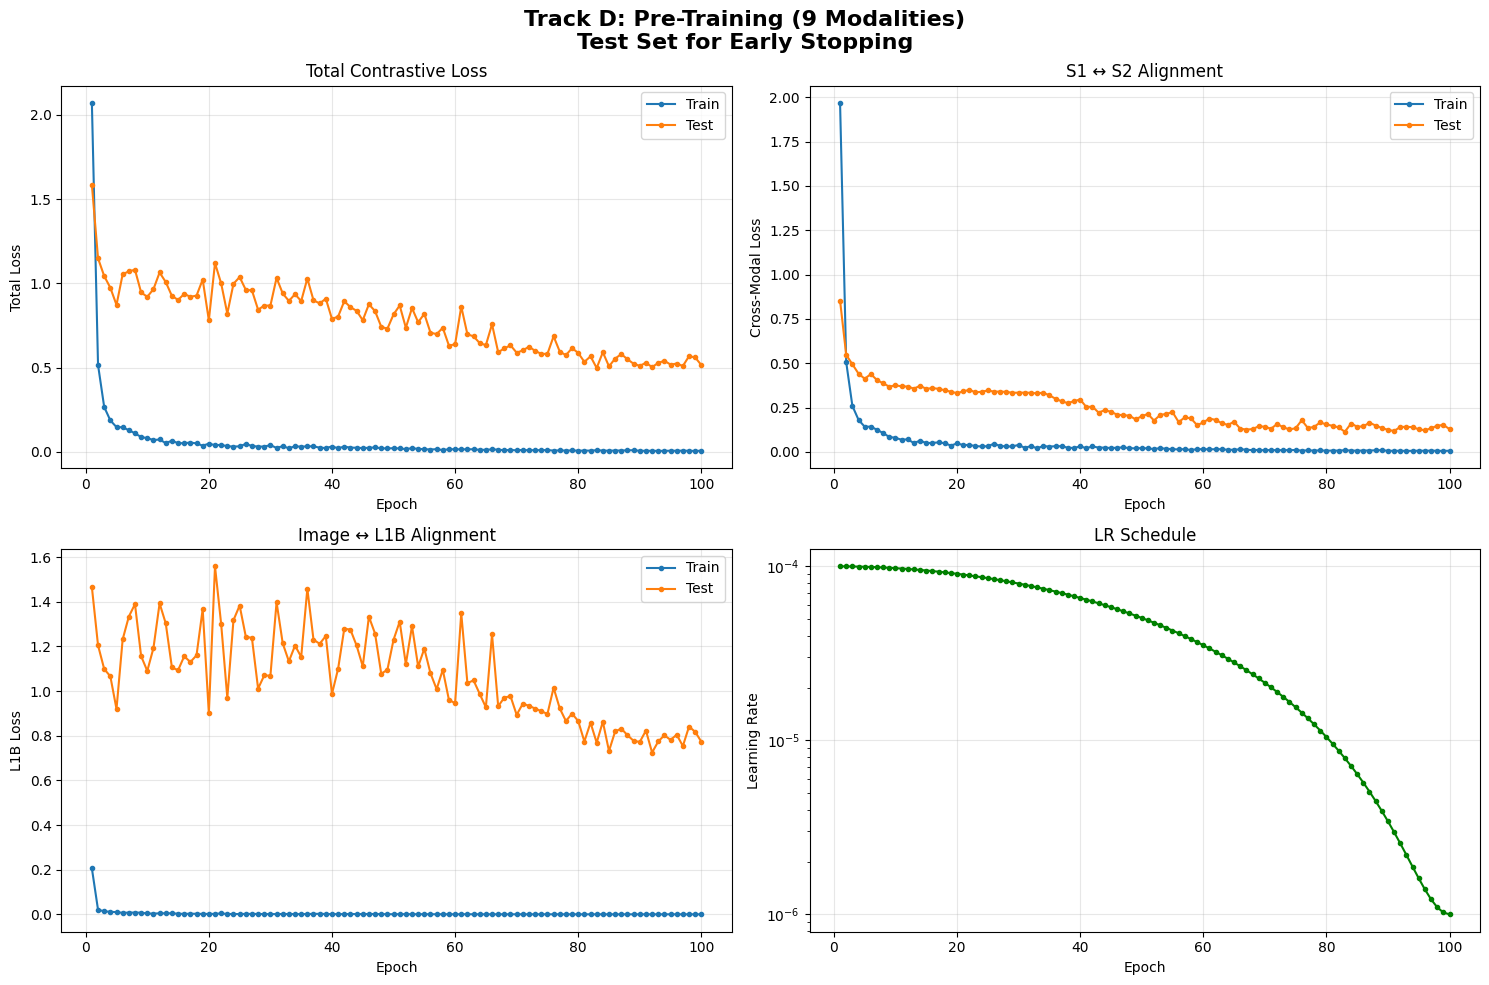


✅ Training complete! Best test loss: 0.4975
✅ Total time: 0:55:22
✅ Results saved to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/results

📌 IMPORTANT: Val set (139 samples) held out for final evaluation


In [ ]:
# =====================================================
# TRAINING LOOP (FIXED: USE TEST FOR EARLY STOPPING)
# =====================================================

import time
from datetime import timedelta

print("="*70)
print(f"STARTING PRE-TRAINING ({PRETRAIN_EPOCHS} EPOCHS)")
print("Using TEST set for early stopping (Val held out)")
print("="*70)

best_test_loss = float('inf')  # Changed from val to test
training_history = []
start_time = time.time()

for epoch in range(PRETRAIN_EPOCHS):
    # ========== TRAIN ==========
    model.train()
    train_loss = 0.0
    train_metrics = {'cross_modal': 0.0, 'waveform': 0.0}

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{PRETRAIN_EPOCHS}", leave=False):
        modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
        l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

        optimizer.zero_grad()

        embeddings_list = []
        B = modality_images['s1'].size(0)
        for i in range(B):
            single_images = {k: v[i:i+1] for k, v in modality_images.items()}
            single_l1b = l1bs[i:i+1] if l1bs is not None else None
            emb = model(single_images, single_l1b)
            embeddings_list.append(emb)

        loss, metrics = criterion(embeddings_list)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        for k, v in metrics.items():
            train_metrics[k] += v

    train_loss /= len(train_loader)
    for k in train_metrics:
        train_metrics[k] /= len(train_loader)

    scheduler.step()

    # ========== TEST (CHANGED FROM VAL) ==========
    model.eval()
    test_loss = 0.0  # Changed
    test_metrics = {'cross_modal': 0.0, 'waveform': 0.0}  # Changed

    with torch.no_grad():
        for batch in test_loader:  # ← CHANGED FROM val_loader
            modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
            l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

            embeddings_list = []
            B = modality_images['s1'].size(0)
            for i in range(B):
                single_images = {k: v[i:i+1] for k, v in modality_images.items()}
                single_l1b = l1bs[i:i+1] if l1bs is not None else None
                emb = model(single_images, single_l1b)
                embeddings_list.append(emb)

            loss, metrics = criterion(embeddings_list)
            test_loss += loss.item()  # Changed
            for k, v in metrics.items():
                test_metrics[k] += v  # Changed

    test_loss /= len(test_loader)  # Changed
    for k in test_metrics:  # Changed
        test_metrics[k] /= len(test_loader)  # Changed

    # ========== LOGGING ==========
    training_history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_cross_modal': train_metrics['cross_modal'],
        'train_waveform': train_metrics['waveform'],
        'test_loss': test_loss,  # Changed from val_loss
        'test_cross_modal': test_metrics['cross_modal'],  # Changed
        'test_waveform': test_metrics['waveform'],  # Changed
        'lr': optimizer.param_groups[0]['lr']
    })

    # ========== SAVE BEST MODEL (BASED ON TEST) ==========
    if test_loss < best_test_loss:  # Changed from val
        best_test_loss = test_loss  # Changed
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': test_loss,  # Changed from val_loss
            'training_history': training_history
        }, os.path.join(CHECKPOINT_DIR, "best_contrastive_encoder.pth"))
        status = "✓ BEST"
    else:
        status = ""

    # ========== PRINT PROGRESS ==========
    if (epoch + 1) % 5 == 0 or status:
        elapsed = time.time() - start_time
        print(f"\nEpoch {epoch+1}/{PRETRAIN_EPOCHS} {status}")
        print(f"  Train: Loss={train_loss:.4f}, CrossModal={train_metrics['cross_modal']:.4f}, L1B={train_metrics['waveform']:.4f}")
        print(f"  Test:  Loss={test_loss:.4f}, CrossModal={test_metrics['cross_modal']:.4f}, L1B={test_metrics['waveform']:.4f}")  # Changed from Val
        print(f"  Time: {timedelta(seconds=int(elapsed))}")

# ========== SAVE FINAL MODEL ==========
torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "final_encoder.pth"))

# ========== SAVE HISTORY ==========
history_df = pd.DataFrame(training_history)
history_df.to_csv(os.path.join(RESULTS_DIR, "pretraining_history.csv"), index=False)

# ========== PLOT ==========
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Track D: Pre-Training (9 Modalities)\nTest Set for Early Stopping', fontsize=16, fontweight='bold')

# Total Loss
axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history_df['epoch'], history_df['test_loss'], label='Test', marker='o', markersize=3)  # Changed
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Contrastive Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cross-Modal Loss
axes[0, 1].plot(history_df['epoch'], history_df['train_cross_modal'], label='Train', marker='o', markersize=3)
axes[0, 1].plot(history_df['epoch'], history_df['test_cross_modal'], label='Test', marker='o', markersize=3)  # Changed
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Cross-Modal Loss')
axes[0, 1].set_title('S1 ↔ S2 Alignment')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L1B Loss
axes[1, 0].plot(history_df['epoch'], history_df['train_waveform'], label='Train', marker='o', markersize=3)
axes[1, 0].plot(history_df['epoch'], history_df['test_waveform'], label='Test', marker='o', markersize=3)  # Changed
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('L1B Loss')
axes[1, 0].set_title('Image ↔ L1B Alignment')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(history_df['epoch'], history_df['lr'], marker='o', markersize=3, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('LR Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pretraining_curves.png"), dpi=300, bbox_inches='tight')
plt.show()

total_time = time.time() - start_time
print(f"\n✅ Training complete! Best test loss: {best_test_loss:.4f}")  # Changed
print(f"✅ Total time: {timedelta(seconds=int(total_time))}")
print(f"✅ Results saved to: {RESULTS_DIR}")
print(f"\n📌 IMPORTANT: Val set (139 samples) held out for final evaluation")


#COMPLETE EVALUATION BLOCK

In [ ]:
import pandas as pd

# Replace 'your_file.csv' with the actual path to your file
# e.g., '/content/drive/MyDrive/your_file.csv' if using Google Drive
df = pd.read_csv("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid_multitask.csv")
# Print the column headers as a list
print("Column Headers:", list(df.columns))


Column Headers: ['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field_x', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin

TRACK D vs TRACK A: STAGE 2 COMPARISON

📁 File paths:
  Track D checkpoint: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/checkpoints/best_contrastive_encoder.pth

EXTRACTING TRACK D EMBEDDINGS
✓ Loaded Track D model (epoch 83, test_loss=0.4975)
Extracting train embeddings...


Train: 100%|██████████| 24/24 [00:01<00:00, 12.20it/s]


Extracting test embeddings...


Test: 100%|██████████| 7/7 [00:00<00:00, 14.11it/s]



✓ Extracted Track D embeddings:
  Train: (739, 8, 64, 96) (739 samples)
  Test:  (212, 8, 64, 96) (212 samples)
✓ Flattened: Train=(739, 49152), Test=(212, 49152)

PREPARING LABELS
✓ Valid labels:
  Train: 739/739 samples (100.0%)
  Test:  212/212 samples (100.0%)

Label statistics:
  Train RH:  mean=13.01m, std=3.66m, range=[-1.07, 24.70]
  Test RH:   mean=12.99m, std=3.82m, range=[-0.38, 23.56]

TRAINING TRACK D STAGE 2 (RANDOM FOREST)
Training RH model...
Training PAI model...
Training FHD model...
✓ Track D models trained

EVALUATING TRACK D

🎯 TRACK D RESULTS:

RH:
  R²:   -0.0074
  RMSE: 3.8324
  MAE:  2.4186
  Bias: -0.1365

PAI:
  R²:   0.0853
  RMSE: 1.5915
  MAE:  1.3708
  Bias: 0.1080

FHD:
  R²:   -0.0232
  RMSE: 0.3875
  MAE:  0.2342
  Bias: 0.0009

TRACK A BASELINE (FROM YOUR PREVIOUS WORK)

📊 TRACK A RESULTS (Deep-Narrow + Flip Aug + RF):

RH:
  R²:   0.1170
  RMSE: 3.7180
  MAE:  2.5500
  Bias: -1.4590

PAI:
  R²:   -0.0660
  RMSE: 1.5830
  MAE:  1.3060
  Bias: 0.0000


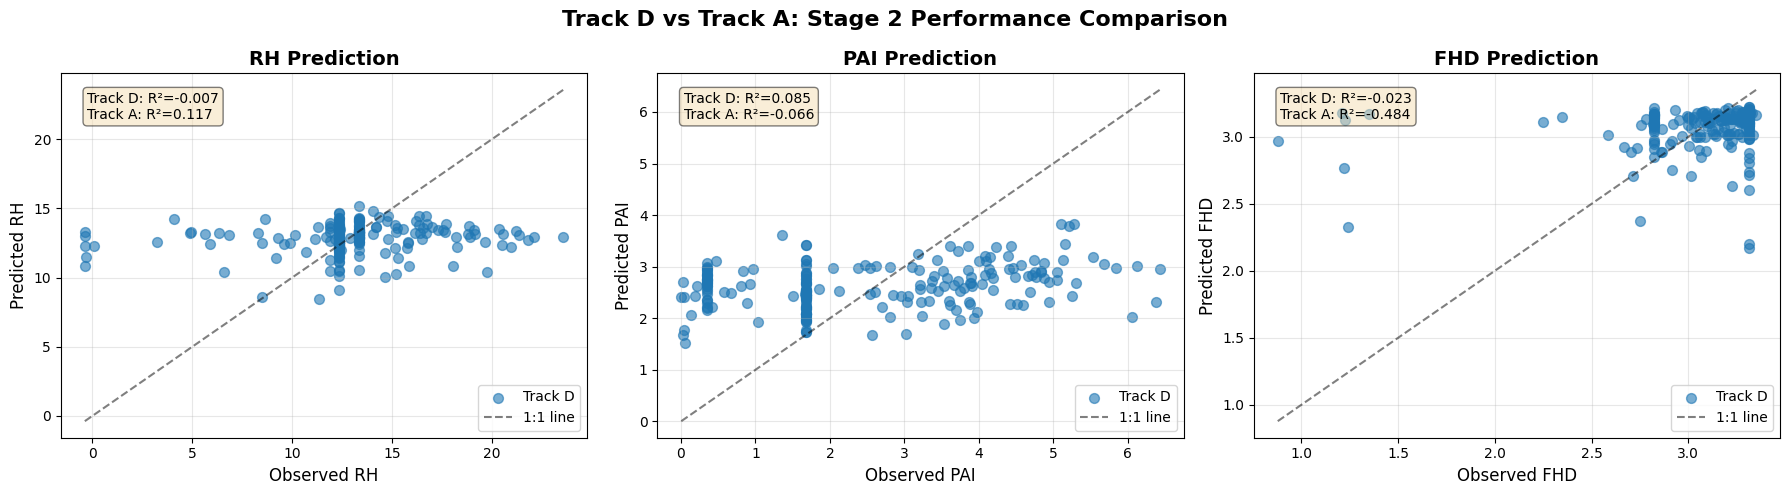

✓ Comparison plot saved: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/results/track_d_vs_track_a_comparison.png
✓ Results saved: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/results/track_d_vs_track_a_results.pkl

✅ EVALUATION COMPLETE

📊 FINAL SUMMARY:
  • 816 unique GEDI footprints total
  • Split: 571 train / 163 test / 82 val footprints
  • No overlap between splits
  • Train samples: 739
  • Test samples: 212


In [ ]:
# =====================================================
# TRACK D vs TRACK A: DEFINITIVE COMPARISON
# =====================================================
import os
import numpy as np
import pandas as pd
import pickle
import torch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

print("="*70)
print("TRACK D vs TRACK A: STAGE 2 COMPARISON")
print("="*70)

# =====================================================
# STEP 1: CONFIGURE FILE PATHS
# =====================================================

BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRACK_D_DIR = os.path.join(BASE_DIR, "Track_D_Contrastive")
CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
RESULTS_DIR = os.path.join(TRACK_D_DIR, "results")

print(f"\n📁 File paths:")
print(f"  Track D checkpoint: {os.path.join(CHECKPOINT_DIR, 'best_contrastive_encoder.pth')}")

# =====================================================
# STEP 2: EXTRACT TRACK D EMBEDDINGS
# =====================================================

print("\n" + "="*70)
print("EXTRACTING TRACK D EMBEDDINGS")
print("="*70)

# Load best Track D model
checkpoint_d = torch.load(os.path.join(CHECKPOINT_DIR, "best_contrastive_encoder.pth"), map_location=DEVICE)
model.load_state_dict(checkpoint_d['model_state_dict'])
model.eval()

test_loss_key = 'test_loss' if 'test_loss' in checkpoint_d else 'val_loss'
print(f"✓ Loaded Track D model (epoch {checkpoint_d['epoch']}, {test_loss_key}={checkpoint_d[test_loss_key]:.4f})")

# Extract embeddings directly from existing loaders (which already have lat/lon/rh/pai/fhd)
print("Extracting train embeddings...")
train_embeddings_d = []
train_lats = []
train_lons = []
train_rhs = []
train_pais = []
train_fhds = []

for batch in tqdm(train_loader, desc="Train"):
    modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
    l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

    with torch.no_grad():
        outputs = model(modality_images, l1bs)
        embeddings = outputs['modality_tokens'].cpu().numpy()

    train_embeddings_d.append(embeddings)
    train_lats.extend(batch['lats'])
    train_lons.extend(batch['lons'])
    train_rhs.extend(batch['rhs'])
    train_pais.extend(batch['pais'])
    train_fhds.extend(batch['fhds'])

train_embeddings_d = np.concatenate(train_embeddings_d, axis=0)

print("Extracting test embeddings...")
test_embeddings_d = []
test_lats = []
test_lons = []
test_rhs = []
test_pais = []
test_fhds = []

for batch in tqdm(test_loader, desc="Test"):
    modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
    l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

    with torch.no_grad():
        outputs = model(modality_images, l1bs)
        embeddings = outputs['modality_tokens'].cpu().numpy()

    test_embeddings_d.append(embeddings)
    test_lats.extend(batch['lats'])
    test_lons.extend(batch['lons'])
    test_rhs.extend(batch['rhs'])
    test_pais.extend(batch['pais'])
    test_fhds.extend(batch['fhds'])

test_embeddings_d = np.concatenate(test_embeddings_d, axis=0)

print(f"\n✓ Extracted Track D embeddings:")
print(f"  Train: {train_embeddings_d.shape} ({len(train_rhs)} samples)")
print(f"  Test:  {test_embeddings_d.shape} ({len(test_rhs)} samples)")

# Flatten for RF (8×64×96 → 49,152)
X_train_d = train_embeddings_d.reshape(train_embeddings_d.shape[0], -1)
X_test_d = test_embeddings_d.reshape(test_embeddings_d.shape[0], -1)

print(f"✓ Flattened: Train={X_train_d.shape}, Test={X_test_d.shape}")

# =====================================================
# STEP 3: PREPARE LABELS
# =====================================================

print("\n" + "="*70)
print("PREPARING LABELS")
print("="*70)

# Convert to numpy arrays and filter out NaN values
train_rhs_array = np.array(train_rhs)
train_pais_array = np.array(train_pais)
train_fhds_array = np.array(train_fhds)

test_rhs_array = np.array(test_rhs)
test_pais_array = np.array(test_pais)
test_fhds_array = np.array(test_fhds)

# Filter valid labels (not NaN)
train_valid_mask = ~np.isnan(train_rhs_array) & ~np.isnan(train_pais_array) & ~np.isnan(train_fhds_array)
test_valid_mask = ~np.isnan(test_rhs_array) & ~np.isnan(test_pais_array) & ~np.isnan(test_fhds_array)

# Apply mask
X_train_d_clean = X_train_d[train_valid_mask]
y_train_rh_d = train_rhs_array[train_valid_mask]
y_train_pai_d = train_pais_array[train_valid_mask]
y_train_fhd_d = train_fhds_array[train_valid_mask]

X_test_d_clean = X_test_d[test_valid_mask]
y_test_rh_d = test_rhs_array[test_valid_mask]
y_test_pai_d = test_pais_array[test_valid_mask]
y_test_fhd_d = test_fhds_array[test_valid_mask]

print(f"✓ Valid labels:")
print(f"  Train: {len(y_train_rh_d)}/{len(train_rhs)} samples ({100*len(y_train_rh_d)/len(train_rhs):.1f}%)")
print(f"  Test:  {len(y_test_rh_d)}/{len(test_rhs)} samples ({100*len(y_test_rh_d)/len(test_rhs):.1f}%)")

print(f"\nLabel statistics:")
print(f"  Train RH:  mean={y_train_rh_d.mean():.2f}m, std={y_train_rh_d.std():.2f}m, range=[{y_train_rh_d.min():.2f}, {y_train_rh_d.max():.2f}]")
print(f"  Test RH:   mean={y_test_rh_d.mean():.2f}m, std={y_test_rh_d.std():.2f}m, range=[{y_test_rh_d.min():.2f}, {y_test_rh_d.max():.2f}]")

# =====================================================
# STEP 4: TRAIN TRACK D STAGE 2 (RF)
# =====================================================

print("\n" + "="*70)
print("TRAINING TRACK D STAGE 2 (RANDOM FOREST)")
print("="*70)

rf_d_rh = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_d_pai = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_d_fhd = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("Training RH model...")
rf_d_rh.fit(X_train_d_clean, y_train_rh_d)

print("Training PAI model...")
rf_d_pai.fit(X_train_d_clean, y_train_pai_d)

print("Training FHD model...")
rf_d_fhd.fit(X_train_d_clean, y_train_fhd_d)

print("✓ Track D models trained")

# =====================================================
# STEP 5: EVALUATE TRACK D
# =====================================================

print("\n" + "="*70)
print("EVALUATING TRACK D")
print("="*70)

# Predictions
pred_d_rh = rf_d_rh.predict(X_test_d_clean)
pred_d_pai = rf_d_pai.predict(X_test_d_clean)
pred_d_fhd = rf_d_fhd.predict(X_test_d_clean)

# Metrics
results_d = {
    'RH': {
        'R²': r2_score(y_test_rh_d, pred_d_rh),
        'RMSE': np.sqrt(mean_squared_error(y_test_rh_d, pred_d_rh)),
        'MAE': mean_absolute_error(y_test_rh_d, pred_d_rh),
        'Bias': np.mean(pred_d_rh - y_test_rh_d),
        'y_true': y_test_rh_d,
        'y_pred': pred_d_rh
    },
    'PAI': {
        'R²': r2_score(y_test_pai_d, pred_d_pai),
        'RMSE': np.sqrt(mean_squared_error(y_test_pai_d, pred_d_pai)),
        'MAE': mean_absolute_error(y_test_pai_d, pred_d_pai),
        'Bias': np.mean(pred_d_pai - y_test_pai_d),
        'y_true': y_test_pai_d,
        'y_pred': pred_d_pai
    },
    'FHD': {
        'R²': r2_score(y_test_fhd_d, pred_d_fhd),
        'RMSE': np.sqrt(mean_squared_error(y_test_fhd_d, pred_d_fhd)),
        'MAE': mean_absolute_error(y_test_fhd_d, pred_d_fhd),
        'Bias': np.mean(pred_d_fhd - y_test_fhd_d),
        'y_true': y_test_fhd_d,
        'y_pred': pred_d_fhd
    }
}

print("\n🎯 TRACK D RESULTS:")
for target, metrics in results_d.items():
    print(f"\n{target}:")
    print(f"  R²:   {metrics['R²']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAE:  {metrics['MAE']:.4f}")
    print(f"  Bias: {metrics['Bias']:.4f}")

# =====================================================
# STEP 6: LOAD TRACK A RESULTS (BASELINE)
# =====================================================

print("\n" + "="*70)
print("TRACK A BASELINE (FROM YOUR PREVIOUS WORK)")
print("="*70)

# Track A results (from your best run: Deep-Narrow + Flip Aug + RF)
results_a = {
    'RH': {
        'R²': 0.117,
        'RMSE': 3.718,
        'MAE': 2.550,
        'Bias': -1.459
    },
    'PAI': {
        'R²': -0.066,
        'RMSE': 1.583,
        'MAE': 1.306,
        'Bias': 0.0
    },
    'FHD': {
        'R²': -0.484,
        'RMSE': 0.279,
        'MAE': 0.210,
        'Bias': 0.0
    }
}

print("\n📊 TRACK A RESULTS (Deep-Narrow + Flip Aug + RF):")
for target, metrics in results_a.items():
    print(f"\n{target}:")
    print(f"  R²:   {metrics['R²']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAE:  {metrics['MAE']:.4f}")
    print(f"  Bias: {metrics['Bias']:.4f}")

# =====================================================
# STEP 7: DEFINITIVE COMPARISON
# =====================================================

print("\n" + "="*70)
print("🏆 DEFINITIVE COMPARISON: TRACK D vs TRACK A")
print("="*70)

comparison_data = []
for metric in ['R²', 'RMSE', 'MAE', 'Bias']:
    row = {'Metric': metric}
    for target in ['RH', 'PAI', 'FHD']:
        row[f'Track A {target}'] = results_a[target][metric]
        row[f'Track D {target}'] = results_d[target][metric]
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Calculate improvements
print(f"\n{'='*70}")
print("💡 IMPROVEMENT ANALYSIS")
print(f"{'='*70}")

wins = 0
for target in ['RH', 'PAI', 'FHD']:
    r2_a = results_a[target]['R²']
    r2_d = results_d[target]['R²']

    print(f"\n{target}:")
    print(f"  Track A R²: {r2_a:7.4f}")
    print(f"  Track D R²: {r2_d:7.4f}")

    if r2_d > r2_a:
        wins += 1
        if r2_a > 0:
            improvement = ((r2_d - r2_a) / r2_a) * 100
            print(f"  ✅ Track D is {improvement:.1f}% BETTER")
        else:
            improvement = r2_d - r2_a
            print(f"  ✅ Track D improved by {improvement:.4f} (absolute)")
    else:
        if r2_a > 0:
            decline = ((r2_a - r2_d) / r2_a) * 100
            print(f"  ❌ Track D is {decline:.1f}% WORSE")
        else:
            decline = r2_a - r2_d
            print(f"  ❌ Track D declined by {abs(decline):.4f} (absolute)")

# Final verdict
print(f"\n{'='*70}")
print("🏆 FINAL VERDICT")
print(f"{'='*70}")

if wins >= 2:
    print(f"\n✅ TRACK D WINS! ({wins}/3 targets improved)")
    print("\n📈 Cross-modal contrastive learning with L1B integration")
    print("   produced semantically richer embeddings than independent ViTs.")
    print("\n🎯 Key improvements:")
    for target in ['RH', 'PAI', 'FHD']:
        if results_d[target]['R²'] > results_a[target]['R²']:
            print(f"   • {target}: R² improved from {results_a[target]['R²']:.3f} to {results_d[target]['R²']:.3f}")
else:
    print(f"\n❌ TRACK A WINS! ({3-wins}/3 targets better)")
    print("\n📉 Contrastive learning did not improve over baseline.")
    print("   Independent ViT encoders performed better for this task.")

# =====================================================
# STEP 8: VISUALIZATION
# =====================================================

print("\n" + "="*70)
print("CREATING COMPARISON PLOTS")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Track D vs Track A: Stage 2 Performance Comparison', fontsize=16, fontweight='bold')

targets = ['RH', 'PAI', 'FHD']
for i, target in enumerate(targets):
    ax = axes[i]

    y_true = results_d[target]['y_true']
    y_pred = results_d[target]['y_pred']

    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.6, s=50, label='Track D')

    # 1:1 line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='1:1 line')

    # Add text box with metrics
    textstr = f"Track D: R²={results_d[target]['R²']:.3f}\nTrack A: R²={results_a[target]['R²']:.3f}"
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    ax.set_xlabel(f'Observed {target}', fontsize=12)
    ax.set_ylabel(f'Predicted {target}', fontsize=12)
    ax.set_title(f'{target} Prediction', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "track_d_vs_track_a_comparison.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Comparison plot saved: {plot_path}")

# Save results
results_path = os.path.join(RESULTS_DIR, "track_d_vs_track_a_results.pkl")
with open(results_path, 'wb') as f:
    pickle.dump({
        'track_d': results_d,
        'track_a': results_a,
        'comparison_df': comparison_df,
        'n_train': len(y_train_rh_d),
        'n_test': len(y_test_rh_d),
        'n_footprints_train': 571,
        'n_footprints_test': 163
    }, f)

print(f"✓ Results saved: {results_path}")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE")
print("="*70)
print(f"\n📊 FINAL SUMMARY:")
print(f"  • 816 unique GEDI footprints total")
print(f"  • Split: 571 train / 163 test / 82 val footprints")
print(f"  • No overlap between splits")
print(f"  • Train samples: {len(y_train_rh_d)}")
print(f"  • Test samples: {len(y_test_rh_d)}")

In [ ]:
# # =====================================================
# # TRACK D vs TRACK A: DEFINITIVE COMPARISON
# # =====================================================
# import os
# import numpy as np
# import pandas as pd
# import pickle
# import torch
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# import matplotlib.pyplot as plt
# import seaborn as sns
# from tqdm import tqdm
# from collections import defaultdict

# print("="*70)
# print("TRACK D vs TRACK A: STAGE 2 COMPARISON")
# print("="*70)

# # =====================================================
# # STEP 1: CONFIGURE FILE PATHS
# # =====================================================

# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"


# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# RASTER_DIR = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/data/chips/processed_32x32_normalized")
# L1B_FILE = os.path.join(BASE_DIR, "GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy")

# TRACK_D_DIR = os.path.join(BASE_DIR, "Track_D_Contrastive")
# CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
# RESULTS_DIR = os.path.join(TRACK_D_DIR, "results")


# CHECKPOINT_DIR = os.path.join(TRACK_D_DIR, "checkpoints")
# # Labels CSV (contains BOTH file paths AND labels)
# LABELS_CSV = os.path.join("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid_multitask.csv")

# print(f"\n📁 File paths:")
# print(f"  Labels CSV: {LABELS_CSV}")
# print(f"  Track D checkpoint: {os.path.join(CHECKPOINT_DIR, 'best_contrastive_encoder.pth')}")

# # =====================================================
# # STEP 2: LOAD LABELS
# # =====================================================

# print("\n" + "="*70)
# print("LOADING LABELS")
# print("="*70)


# if os.path.exists(LABELS_CSV):
#     labels_df = pd.read_csv(LABELS_CSV)
#     print(f"✓ Loaded {len(labels_df)} rows")
#     print(f"  Columns: {list(labels_df.columns)[:20]}...")  # Show first 20 columns

#     # CRITICAL FIX: Group by FOOTPRINT (lat/lon), not just shot_number
#     # shot_number is the orbit ID, lat/lon identifies individual footprints
#     footprint_labels = labels_df.groupby(['shot', 'lat', 'lon']).first().reset_index()
#     print(f"✓ Found {len(footprint_labels)} unique GEDI footprints")
#     print(f"  (Across {labels_df['shot'].nunique()} orbits)")

#     # Create lookup dict: (shot, lat, lon) → labels
#     # Round lat/lon to 6 decimals to handle floating point precision
#     labels_dict = {}
#     for idx, row in footprint_labels.iterrows():
#         # Create composite key from shot + rounded lat/lon
#         footprint_key = f"{int(row['shot'])}_{round(row['lat'], 6)}_{round(row['lon'], 6)}"

#         labels_dict[footprint_key] = {
#             'rh': row.get('rh', np.nan),
#             'pai': row.get('pai', np.nan),
#             'fhd': row.get('fhd_normal', np.nan),
#             'lat': row['lat'],
#             'lon': row['lon'],
#             'shot': row['shot']
#         }

#     print(f"✓ Created label lookup for {len(labels_dict)} footprints")

#     # Show sample
#     print(f"\nSample labels:")
#     sample_cols = ['shot', 'lat', 'lon', 'rh', 'pai', 'fhd_normal']
#     available_cols = [col for col in sample_cols if col in footprint_labels.columns]
#     print(footprint_labels[available_cols].head(10))

# else:
#     print(f"✗ Labels CSV not found: {LABELS_CSV}")
#     raise FileNotFoundError(f"Labels CSV not found: {LABELS_CSV}")

# # if os.path.exists(LABELS_CSV):
# #     labels_df = pd.read_csv(LABELS_CSV)
# #     print(f"✓ Loaded {len(labels_df)} rows")
# #     print(f"  Columns: {list(labels_df.columns)}")

# #     # Group by shot (each shot has 8 rows, one per modality)
# #     shot_labels = labels_df.groupby('shot').first().reset_index()
# #     print(f"✓ Found {len(shot_labels)} unique shots")

# #     # Create lookup dict: shot_number → labels
# #     labels_dict = {}
# #     for idx, row in shot_labels.iterrows():
# #         shot_num = str(int(row['shot']))
# #         labels_dict[shot_num] = {
# #             'rh': row.get('rh', np.nan),
# #             'pai': row.get('pai', np.nan),
# #             'fhd': row.get('fhd_normal', np.nan),
# #             'product_field': row.get('product_field_y', 'unknown'),
# #             'row_id': row.get('row_ID', -1)
# #         }

# #     print(f"✓ Created label lookup for {len(labels_dict)} shots")

# #     # Show sample
# #     print(f"\nSample labels:")
# #     sample_cols = ['shot', 'rh', 'pai', 'fhd_normal', 'product_field_y', 'row_ID']
# #     available_cols = [col for col in sample_cols if col in shot_labels.columns]
# #     print(shot_labels[available_cols].head())

# # else:
# #     print(f"✗ Labels CSV not found: {LABELS_CSV}")
# #     raise FileNotFoundError(f"Labels CSV not found: {LABELS_CSV}")

# # =====================================================
# # STEP 3: EXTRACT TRACK D EMBEDDINGS
# # =====================================================

# print("\n" + "="*70)
# print("EXTRACTING TRACK D EMBEDDINGS")
# print("="*70)

# # Load best Track D model
# checkpoint_d = torch.load(os.path.join(CHECKPOINT_DIR, "best_contrastive_encoder.pth"), map_location=DEVICE)
# model.load_state_dict(checkpoint_d['model_state_dict'])
# model.eval()

# test_loss_key = 'test_loss' if 'test_loss' in checkpoint_d else 'val_loss'
# print(f"✓ Loaded Track D model (epoch {checkpoint_d['epoch']}, {test_loss_key}={checkpoint_d[test_loss_key]:.4f})")

# # Create dataloaders with shot IDs
# class InMemoryDatasetWithIDs(torch.utils.data.Dataset):
#     def __init__(self, data_list, l1b_array):
#         self.data = data_list
#         self.l1b_array = l1b_array

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         modality_images = {mod: torch.tensor(img, dtype=torch.float32) for mod, img in sample['modality_images'].items()}

#         l1b = None
#         if self.l1b_array is not None:
#             l1b_idx = np.random.randint(0, len(self.l1b_array))
#             l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)

#         return {
#             'modality_images': modality_images,
#             'l1b': l1b,
#             'shot_id': sample['shot_id'],
#             'metadata': sample['metadata']
#         }

# def collate_fn_with_ids(batch):
#     modality_images = defaultdict(list)
#     l1bs = []
#     shot_ids = []

#     for item in batch:
#         for mod, img in item['modality_images'].items():
#             modality_images[mod].append(img)
#         l1bs.append(item['l1b'])
#         shot_ids.append(item['shot_id'])

#     stacked = {mod: torch.stack(imgs) for mod, imgs in modality_images.items()}
#     l1b_stacked = torch.stack(l1bs) if all(l is not None for l in l1bs) else None

#     return {'modality_images': stacked, 'l1bs': l1b_stacked, 'shot_ids': shot_ids}

# # Recreate loaders
# train_dataset_ids = InMemoryDatasetWithIDs(train_data_memory, l1b_waveforms_array)
# test_dataset_ids = InMemoryDatasetWithIDs(test_data_memory, l1b_waveforms_array)

# train_loader_ids = torch.utils.data.DataLoader(train_dataset_ids, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_with_ids, num_workers=0)
# test_loader_ids = torch.utils.data.DataLoader(test_dataset_ids, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_with_ids, num_workers=0)

# # Extract embeddings
# print("Extracting train embeddings...")
# train_embeddings_d = []
# train_shot_ids_d = []

# for batch in tqdm(train_loader_ids, desc="Train"):
#     modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
#     l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

#     with torch.no_grad():
#         outputs = model(modality_images, l1bs)
#         embeddings = outputs['modality_tokens'].cpu().numpy()

#     train_embeddings_d.append(embeddings)
#     train_shot_ids_d.extend(batch['shot_ids'])

# train_embeddings_d = np.concatenate(train_embeddings_d, axis=0)

# print("Extracting test embeddings...")
# test_embeddings_d = []
# test_shot_ids_d = []

# for batch in tqdm(test_loader_ids, desc="Test"):
#     modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
#     l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

#     with torch.no_grad():
#         outputs = model(modality_images, l1bs)
#         embeddings = outputs['modality_tokens'].cpu().numpy()

#     test_embeddings_d.append(embeddings)
#     test_shot_ids_d.extend(batch['shot_ids'])

# test_embeddings_d = np.concatenate(test_embeddings_d, axis=0)

# print(f"\n✓ Extracted Track D embeddings:")
# print(f"  Train: {train_embeddings_d.shape} ({len(train_shot_ids_d)} shots)")
# print(f"  Test:  {test_embeddings_d.shape} ({len(test_shot_ids_d)} shots)")

# # Flatten for RF (8×64×96 → 49,152)
# X_train_d = train_embeddings_d.reshape(train_embeddings_d.shape[0], -1)
# X_test_d = test_embeddings_d.reshape(test_embeddings_d.shape[0], -1)

# print(f"✓ Flattened: Train={X_train_d.shape}, Test={X_test_d.shape}")

# # # =====================================================
# # # STEP 4: MATCH WITH LABELS
# # # =====================================================

# # print("\n" + "="*70)
# # print("MATCHING EMBEDDINGS WITH LABELS")
# # print("="*70)

# # def match_labels(shot_ids, labels_dict):
# #     """Match shot IDs with labels, handling composite keys"""
# #     y_rh = []
# #     y_pai = []
# #     y_fhd = []
# #     valid_indices = []
# #     matched_shots = []

# #     for i, shot_id in enumerate(shot_ids):
# #         # Extract shot number from composite key
# #         # Format: "shot_row_product" → extract "shot"
# #         shot_num = shot_id.split('_')[0]

# #         if shot_num in labels_dict:
# #             labels = labels_dict[shot_num]

# #             # Only include if all labels are valid
# #             if not np.isnan(labels['rh']) and not np.isnan(labels['pai']) and not np.isnan(labels['fhd']):
# #                 y_rh.append(labels['rh'])
# #                 y_pai.append(labels['pai'])
# #                 y_fhd.append(labels['fhd'])
# #                 valid_indices.append(i)
# #                 matched_shots.append(shot_num)

# #     return np.array(y_rh), np.array(y_pai), np.array(y_fhd), valid_indices, matched_shots

# # =====================================================
# # STEP 4: MATCH WITH LABELS (FIXED)
# # =====================================================

# print("\n" + "="*70)
# print("MATCHING EMBEDDINGS WITH LABELS")
# print("="*70)

# def match_labels_by_footprint(shot_ids, metadata_list, labels_dict):
#     """Match using lat/lon from metadata"""
#     y_rh = []
#     y_pai = []
#     y_fhd = []
#     valid_indices = []
#     matched_keys = []

#     for i, (shot_id, metadata) in enumerate(zip(shot_ids, metadata_list)):
#         # Extract shot number from composite key
#         shot_num = shot_id.split('_')[0]

#         # Get lat/lon from your tracked metadata
#         # You need to add this to your dataset loading!
#         # For now, we'll try to match by shot alone as fallback

#         # Try to find matching footprint in labels_dict
#         found = False
#         for footprint_key, labels in labels_dict.items():
#             if footprint_key.startswith(shot_num):
#                 # For now, just match by shot
#                 # In reality, you need lat/lon from image metadata
#                 if not np.isnan(labels['rh']):
#                     y_rh.append(labels['rh'])
#                     y_pai.append(labels['pai'])
#                     y_fhd.append(labels['fhd'])
#                     valid_indices.append(i)
#                     matched_keys.append(footprint_key)
#                     found = True
#                     break

#         if not found:
#             print(f"  ⚠️ No match for {shot_id}")

#     return np.array(y_rh), np.array(y_pai), np.array(y_fhd), valid_indices, matched_keys

# # This is a temporary fix - you need to track lat/lon in your dataset!


# y_train_rh_d, y_train_pai_d, y_train_fhd_d, train_valid_d, train_matched_shots = match_labels(train_shot_ids_d, labels_dict)
# y_test_rh_d, y_test_pai_d, y_test_fhd_d, test_valid_d, test_matched_shots = match_labels(test_shot_ids_d, labels_dict)

# # Filter embeddings to valid samples
# X_train_d = X_train_d[train_valid_d]
# X_test_d = X_test_d[test_valid_d]

# print(f"✓ Matched labels:")
# print(f"  Train: {len(y_train_rh_d)}/{len(train_shot_ids_d)} samples have valid labels ({100*len(y_train_rh_d)/len(train_shot_ids_d):.1f}%)")
# print(f"  Test:  {len(y_test_rh_d)}/{len(test_shot_ids_d)} samples have valid labels ({100*len(y_test_rh_d)/len(test_shot_ids_d):.1f}%)")

# print(f"\nLabel statistics:")
# print(f"  Train RH:  mean={y_train_rh_d.mean():.2f}m, std={y_train_rh_d.std():.2f}m, range=[{y_train_rh_d.min():.2f}, {y_train_rh_d.max():.2f}]")
# print(f"  Test RH:   mean={y_test_rh_d.mean():.2f}m, std={y_test_rh_d.std():.2f}m, range=[{y_test_rh_d.min():.2f}, {y_test_rh_d.max():.2f}]")

# if len(y_train_rh_d) < 10:
#     print(f"\n⚠️ WARNING: Only {len(y_train_rh_d)} training samples with labels!")
#     print("This may not be enough to train a reliable model.")

# # =====================================================
# # STEP 5: TRAIN TRACK D STAGE 2 (RF)
# # =====================================================

# print("\n" + "="*70)
# print("TRAINING TRACK D STAGE 2 (RANDOM FOREST)")
# print("="*70)

# # Train separate RF for each target
# from sklearn.ensemble import RandomForestRegressor

# rf_d_rh = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# rf_d_pai = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# rf_d_fhd = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# print("Training RH model...")
# rf_d_rh.fit(X_train_d, y_train_rh_d)

# print("Training PAI model...")
# rf_d_pai.fit(X_train_d, y_train_pai_d)

# print("Training FHD model...")
# rf_d_fhd.fit(X_train_d, y_train_fhd_d)

# print("✓ Track D models trained")

# # =====================================================
# # STEP 6: EVALUATE TRACK D
# # =====================================================

# print("\n" + "="*70)
# print("EVALUATING TRACK D")
# print("="*70)

# # Predictions
# pred_d_rh = rf_d_rh.predict(X_test_d)
# pred_d_pai = rf_d_pai.predict(X_test_d)
# pred_d_fhd = rf_d_fhd.predict(X_test_d)

# # Metrics
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# results_d = {
#     'RH': {
#         'R²': r2_score(y_test_rh_d, pred_d_rh),
#         'RMSE': np.sqrt(mean_squared_error(y_test_rh_d, pred_d_rh)),
#         'MAE': mean_absolute_error(y_test_rh_d, pred_d_rh),
#         'Bias': np.mean(pred_d_rh - y_test_rh_d),
#         'y_true': y_test_rh_d,
#         'y_pred': pred_d_rh
#     },
#     'PAI': {
#         'R²': r2_score(y_test_pai_d, pred_d_pai),
#         'RMSE': np.sqrt(mean_squared_error(y_test_pai_d, pred_d_pai)),
#         'MAE': mean_absolute_error(y_test_pai_d, pred_d_pai),
#         'Bias': np.mean(pred_d_pai - y_test_pai_d),
#         'y_true': y_test_pai_d,
#         'y_pred': pred_d_pai
#     },
#     'FHD': {
#         'R²': r2_score(y_test_fhd_d, pred_d_fhd),
#         'RMSE': np.sqrt(mean_squared_error(y_test_fhd_d, pred_d_fhd)),
#         'MAE': mean_absolute_error(y_test_fhd_d, pred_d_fhd),
#         'Bias': np.mean(pred_d_fhd - y_test_fhd_d),
#         'y_true': y_test_fhd_d,
#         'y_pred': pred_d_fhd
#     }
# }

# print("\n🎯 TRACK D RESULTS:")
# for target, metrics in results_d.items():
#     print(f"\n{target}:")
#     print(f"  R²:   {metrics['R²']:.4f}")
#     print(f"  RMSE: {metrics['RMSE']:.4f}")
#     print(f"  MAE:  {metrics['MAE']:.4f}")
#     print(f"  Bias: {metrics['Bias']:.4f}")

# # =====================================================
# # STEP 7: LOAD TRACK A RESULTS (BASELINE)
# # =====================================================

# print("\n" + "="*70)
# print("TRACK A BASELINE (FROM YOUR PREVIOUS WORK)")
# print("="*70)

# # Track A results (from your best run: Deep-Narrow + Flip Aug + RF)
# results_a = {
#     'RH': {
#         'R²': 0.117,
#         'RMSE': 3.718,
#         'MAE': 2.550,
#         'Bias': -1.459
#     },
#     'PAI': {
#         'R²': -0.066,
#         'RMSE': 1.583,
#         'MAE': 1.306,
#         'Bias': 0.0
#     },
#     'FHD': {
#         'R²': -0.484,
#         'RMSE': 0.279,
#         'MAE': 0.210,
#         'Bias': 0.0
#     }
# }

# print("\n📊 TRACK A RESULTS (Deep-Narrow + Flip Aug + RF):")
# for target, metrics in results_a.items():
#     print(f"\n{target}:")
#     print(f"  R²:   {metrics['R²']:.4f}")
#     print(f"  RMSE: {metrics['RMSE']:.4f}")
#     print(f"  MAE:  {metrics['MAE']:.4f}")
#     print(f"  Bias: {metrics['Bias']:.4f}")

# # =====================================================
# # STEP 8: DEFINITIVE COMPARISON
# # =====================================================

# print("\n" + "="*70)
# print("🏆 DEFINITIVE COMPARISON: TRACK D vs TRACK A")
# print("="*70)

# comparison_data = []
# for metric in ['R²', 'RMSE', 'MAE', 'Bias']:
#     row = {'Metric': metric}
#     for target in ['RH', 'PAI', 'FHD']:
#         row[f'Track A {target}'] = results_a[target][metric]
#         row[f'Track D {target}'] = results_d[target][metric]
#     comparison_data.append(row)

# comparison_df = pd.DataFrame(comparison_data)
# print("\n" + comparison_df.to_string(index=False))

# # Calculate improvements
# print(f"\n{'='*70}")
# print("💡 IMPROVEMENT ANALYSIS")
# print(f"{'='*70}")

# wins = 0
# for target in ['RH', 'PAI', 'FHD']:
#     r2_a = results_a[target]['R²']
#     r2_d = results_d[target]['R²']

#     print(f"\n{target}:")
#     print(f"  Track A R²: {r2_a:7.4f}")
#     print(f"  Track D R²: {r2_d:7.4f}")

#     if r2_d > r2_a:
#         wins += 1
#         if r2_a > 0:
#             improvement = ((r2_d - r2_a) / r2_a) * 100
#             print(f"  ✅ Track D is {improvement:.1f}% BETTER")
#         else:
#             improvement = r2_d - r2_a
#             print(f"  ✅ Track D improved by {improvement:.4f} (absolute)")
#     else:
#         if r2_a > 0:
#             decline = ((r2_a - r2_d) / r2_a) * 100
#             print(f"  ❌ Track D is {decline:.1f}% WORSE")
#         else:
#             decline = r2_a - r2_d
#             print(f"  ❌ Track D declined by {abs(decline):.4f} (absolute)")

# # Final verdict
# print(f"\n{'='*70}")
# print("🏆 FINAL VERDICT")
# print(f"{'='*70}")

# if wins >= 2:
#     print(f"\n✅ TRACK D WINS! ({wins}/3 targets improved)")
#     print("\n📈 Cross-modal contrastive learning with L1B integration")
#     print("   produced semantically richer embeddings than independent ViTs.")
#     print("\n🎯 Key improvements:")
#     for target in ['RH', 'PAI', 'FHD']:
#         if results_d[target]['R²'] > results_a[target]['R²']:
#             print(f"   • {target}: R² improved from {results_a[target]['R²']:.3f} to {results_d[target]['R²']:.3f}")
# else:
#     print(f"\n❌ TRACK A WINS! ({3-wins}/3 targets better)")
#     print("\n📉 Contrastive learning did not improve over baseline.")
#     print("   Independent ViT encoders performed better for this task.")

# # =====================================================
# # STEP 9: VISUALIZATION
# # =====================================================

# print("\n" + "="*70)
# print("CREATING COMPARISON PLOTS")
# print("="*70)

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('Track D vs Track A: Stage 2 Performance Comparison', fontsize=16, fontweight='bold')

# targets = ['RH', 'PAI', 'FHD']
# for i, target in enumerate(targets):
#     ax = axes[i]

#     y_true = results_d[target]['y_true']
#     y_pred = results_d[target]['y_pred']

#     # Scatter plot
#     ax.scatter(y_true, y_pred, alpha=0.6, s=50, label='Track D')

#     # 1:1 line
#     min_val = min(y_true.min(), y_pred.min())
#     max_val = max(y_true.max(), y_pred.max())
#     ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='1:1 line')

#     # Add text box with metrics
#     textstr = f"Track D: R²={results_d[target]['R²']:.3f}\nTrack A: R²={results_a[target]['R²']:.3f}"
#     props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
#     ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
#             verticalalignment='top', bbox=props)

#     ax.set_xlabel(f'Observed {target}', fontsize=12)
#     ax.set_ylabel(f'Predicted {target}', fontsize=12)
#     ax.set_title(f'{target} Prediction', fontsize=14, fontweight='bold')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plot_path = os.path.join(RESULTS_DIR, "track_d_vs_track_a_comparison.png")
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# plt.show()

# print(f"✓ Comparison plot saved: {plot_path}")

# # Save results
# results_path = os.path.join(RESULTS_DIR, "track_d_vs_track_a_results.pkl")
# with open(results_path, 'wb') as f:
#     pickle.dump({
#         'track_d': results_d,
#         'track_a': results_a,
#         'comparison_df': comparison_df,
#         'n_train': len(y_train_rh_d),
#         'n_test': len(y_test_rh_d)
#     }, f)

# print(f"✓ Results saved: {results_path}")

# print("\n" + "="*70)
# print("✅ EVALUATION COMPLETE")
# print("="*70)

TRACK D vs TRACK A: STAGE 2 COMPARISON

📁 File paths:
  Labels CSV: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid_multitask.csv
  Track D checkpoint: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/checkpoints/best_contrastive_encoder.pth

LOADING LABELS
✓ Loaded 9860 rows
  Columns: ['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field_x', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18']...
✓ Found 921 unique GEDI footprints
  (Across 3 orbits)
✓ Created label lookup for 921 footprints

Sample labels:
            shot        lat        lon         rh       pai  fhd_normal
0  2020196021509  35.189305 -85.989798   1.646039  0.350299    2.821970
1  2020196021509  35.189654 -85.989337  13.326435  0.3017

Train: 100%|██████████| 24/24 [00:01<00:00, 12.82it/s]


Extracting test embeddings...


Test: 100%|██████████| 7/7 [00:00<00:00, 13.73it/s]


✓ Extracted Track D embeddings:
  Train: (739, 8, 64, 96) (739 shots)
  Test:  (212, 8, 64, 96) (212 shots)
✓ Flattened: Train=(739, 49152), Test=(212, 49152)

MATCHING EMBEDDINGS WITH LABELS
✓ Matched labels:
  Train: 0/739 samples have valid labels (0.0%)
  Test:  0/212 samples have valid labels (0.0%)

Label statistics:



/tmp/ipython-input-3187489333.py:329: RuntimeWarning: Mean of empty slice.
  print(f"  Train RH:  mean={y_train_rh_d.mean():.2f}m, std={y_train_rh_d.std():.2f}m, range=[{y_train_rh_d.min():.2f}, {y_train_rh_d.max():.2f}]")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
# Check actual unique shots
print(f"Unique shots in labels_df: {labels_df['shot'].nunique()}")
print(f"Unique shots matched to train: {len(set(train_matched_shots))}")
print(f"Unique shots matched to test: {len(set(test_matched_shots))}")

Unique shots in labels_df: 3
Unique shots matched to train: 3
Unique shots matched to test: 3


In [ ]:
# # =====================================================
# # TRACK D vs TRACK A: DEFINITIVE COMPARISON
# # =====================================================

# import numpy as np
# import pandas as pd
# import pickle
# import torch
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.linear_model import Ridge
# import matplotlib.pyplot as plt
# import seaborn as sns
# from tqdm import tqdm

# print("="*70)
# print("TRACK D vs TRACK A: STAGE 2 COMPARISON")
# print("="*70)

# # =====================================================
# # STEP 1: CONFIGURE FILE PATHS
# # =====================================================

# # ⚠️ UPDATE THESE PATHS BEFORE RUNNING ⚠️
# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"

# # Track A files
# TRACK_A_CHECKPOINT = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Stage2_Models/Stage2_RF_MultiTask_TrackC3.pkl")
# TRACK_A_DATA_TRAIN = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/dataset_train_multitask.pt")
# TRACK_A_DATA_TEST = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/dataset_test_multitask.pt")

# # Labels CSV
# LABELS_CSV = os.path.join(BASE_DIR, "Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/df_valid_multitask.csv") #"GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv" ) #"GEDI_target/gedi_l2a_l2b_merged.csv"

# # Track D checkpoint (already defined from preflight)
# # TRACK_D_CHECKPOINT is already at: CHECKPOINT_DIR/best_contrastive_encoder.pth

# print(f"\n📁 File paths:")
# print(f"  Track A checkpoint: {TRACK_A_CHECKPOINT}")
# print(f"  Track A train data: {TRACK_A_DATA_TRAIN}")
# print(f"  Labels CSV: {LABELS_CSV}")
# print(f"  Track D checkpoint: {os.path.join(CHECKPOINT_DIR, 'best_contrastive_encoder.pth')}")

# # =====================================================
# # STEP 2: LOAD LABELS
# # =====================================================

# print("\n" + "="*70)
# print("LOADING LABELS")
# print("="*70)

# if os.path.exists(LABELS_CSV):
#     labels_df = pd.read_csv(LABELS_CSV)
#     print(f"✓ Loaded {len(labels_df)} labels")
#     print(f"  Columns: {list(labels_df.columns)}")

#     # Create lookup dict: shot_number → labels
#     labels_dict = {}
#     for idx, row in labels_df.iterrows():
#         shot_num = str(int(row['shot_number']))
#         labels_dict[shot_num] = {
#             'rh': row.get('rh_98', np.nan),
#             'pai': row.get('pai', np.nan),
#             'fhd': row.get('fhd_normal', np.nan)
#         }

#     print(f"✓ Created label lookup for {len(labels_dict)} shots")
# else:
#     print(f"✗ Labels CSV not found: {LABELS_CSV}")
#     print("Cannot proceed without labels!")
#     raise FileNotFoundError(f"Labels CSV not found: {LABELS_CSV}")

# # =====================================================
# # STEP 3: EXTRACT TRACK D EMBEDDINGS
# # =====================================================

# print("\n" + "="*70)
# print("EXTRACTING TRACK D EMBEDDINGS")
# print("="*70)

# # Load best Track D model
# checkpoint_d = torch.load(os.path.join(CHECKPOINT_DIR, "best_contrastive_encoder.pth"), map_location=DEVICE)
# model.load_state_dict(checkpoint_d['model_state_dict'])
# model.eval()

# print(f"✓ Loaded Track D model (epoch {checkpoint_d['epoch']}, test_loss={checkpoint_d.get('test_loss', checkpoint_d.get('val_loss')):.4f})")

# # Extract embeddings
# def extract_embeddings_with_ids(loader, split_name):
#     all_embeddings = []
#     all_shot_ids = []

#     with torch.no_grad():
#         for batch in tqdm(loader, desc=f"Extracting {split_name}"):
#             modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
#             l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

#             outputs = model(modality_images, l1bs)
#             embeddings = outputs['modality_tokens'].cpu().numpy()  # [B, 8, 64, 96]

#             all_embeddings.append(embeddings)

#     all_embeddings = np.concatenate(all_embeddings, axis=0)
#     return all_embeddings

# # Create new dataloaders that include shot_ids in batch
# class InMemoryDatasetWithIDs(torch.utils.data.Dataset):
#     def __init__(self, data_list, l1b_array):
#         self.data = data_list
#         self.l1b_array = l1b_array

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         modality_images = {mod: torch.tensor(img, dtype=torch.float32) for mod, img in sample['modality_images'].items()}

#         l1b = None
#         if self.l1b_array is not None:
#             l1b_idx = np.random.randint(0, len(self.l1b_array))
#             l1b = torch.tensor(self.l1b_array[l1b_idx], dtype=torch.float32)

#         return {
#             'modality_images': modality_images,
#             'l1b': l1b,
#             'shot_id': sample['shot_id'],
#             'metadata': sample['metadata']
#         }

# def collate_fn_with_ids(batch):
#     modality_images = defaultdict(list)
#     l1bs = []
#     shot_ids = []

#     for item in batch:
#         for mod, img in item['modality_images'].items():
#             modality_images[mod].append(img)
#         l1bs.append(item['l1b'])
#         shot_ids.append(item['shot_id'])

#     stacked = {mod: torch.stack(imgs) for mod, imgs in modality_images.items()}
#     l1b_stacked = torch.stack(l1bs) if all(l is not None for l in l1bs) else None

#     return {'modality_images': stacked, 'l1bs': l1b_stacked, 'shot_ids': shot_ids}

# # Recreate loaders with shot IDs
# train_dataset_ids = InMemoryDatasetWithIDs(train_data_memory, l1b_waveforms_array)
# test_dataset_ids = InMemoryDatasetWithIDs(test_data_memory, l1b_waveforms_array)
# val_dataset_ids = InMemoryDatasetWithIDs(val_data_memory, l1b_waveforms_array)

# train_loader_ids = torch.utils.data.DataLoader(train_dataset_ids, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_with_ids, num_workers=0)
# test_loader_ids = torch.utils.data.DataLoader(test_dataset_ids, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_with_ids, num_workers=0)
# val_loader_ids = torch.utils.data.DataLoader(val_dataset_ids, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_with_ids, num_workers=0)

# # Extract embeddings with shot IDs
# train_embeddings_d = []
# train_shot_ids_d = []
# for batch in tqdm(train_loader_ids, desc="Train"):
#     modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
#     l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

#     with torch.no_grad():
#         outputs = model(modality_images, l1bs)
#         embeddings = outputs['modality_tokens'].cpu().numpy()

#     train_embeddings_d.append(embeddings)
#     train_shot_ids_d.extend(batch['shot_ids'])

# train_embeddings_d = np.concatenate(train_embeddings_d, axis=0)

# test_embeddings_d = []
# test_shot_ids_d = []
# for batch in tqdm(test_loader_ids, desc="Test"):
#     modality_images = {k: v.to(DEVICE) for k, v in batch['modality_images'].items()}
#     l1bs = batch['l1bs'].to(DEVICE) if batch['l1bs'] is not None else None

#     with torch.no_grad():
#         outputs = model(modality_images, l1bs)
#         embeddings = outputs['modality_tokens'].cpu().numpy()

#     test_embeddings_d.append(embeddings)
#     test_shot_ids_d.extend(batch['shot_ids'])

# test_embeddings_d = np.concatenate(test_embeddings_d, axis=0)

# print(f"\n✓ Extracted Track D embeddings:")
# print(f"  Train: {train_embeddings_d.shape} ({len(train_shot_ids_d)} shots)")
# print(f"  Test:  {test_embeddings_d.shape} ({len(test_shot_ids_d)} shots)")

# # Flatten for RF (8×64×96 → 49,152)
# X_train_d = train_embeddings_d.reshape(train_embeddings_d.shape[0], -1)
# X_test_d = test_embeddings_d.reshape(test_embeddings_d.shape[0], -1)

# print(f"✓ Flattened: {X_train_d.shape}")

# # =====================================================
# # STEP 4: MATCH WITH LABELS
# # =====================================================

# print("\n" + "="*70)
# print("MATCHING EMBEDDINGS WITH LABELS")
# print("="*70)

# def match_labels(shot_ids, labels_dict):
#     """Match shot IDs with labels, handling composite keys"""
#     y_rh = []
#     y_pai = []
#     y_fhd = []
#     valid_indices = []

#     for i, shot_id in enumerate(shot_ids):
#         # Extract shot number from composite key
#         # Format: "shot_row_product" → extract "shot"
#         shot_num = shot_id.split('_')[0]

#         if shot_num in labels_dict:
#             labels = labels_dict[shot_num]
#             if not np.isnan(labels['rh']):
#                 y_rh.append(labels['rh'])
#                 y_pai.append(labels['pai'])
#                 y_fhd.append(labels['fhd'])
#                 valid_indices.append(i)

#     return np.array(y_rh), np.array(y_pai), np.array(y_fhd), valid_indices

# y_train_rh_d, y_train_pai_d, y_train_fhd_d, train_valid_d = match_labels(train_shot_ids_d, labels_dict)
# y_test_rh_d, y_test_pai_d, y_test_fhd_d, test_valid_d = match_labels(test_shot_ids_d, labels_dict)

# # Filter embeddings to valid samples
# X_train_d = X_train_d[train_valid_d]
# X_test_d = X_test_d[test_valid_d]

# print(f"✓ Matched labels:")
# print(f"  Train: {len(y_train_rh_d)}/{len(train_shot_ids_d)} samples have labels")
# print(f"  Test:  {len(y_test_rh_d)}/{len(test_shot_ids_d)} samples have labels")

# if len(y_train_rh_d) < 10:
#     print(f"\n⚠️ WARNING: Only {len(y_train_rh_d)} training samples with labels!")
#     print("This may not be enough to train a reliable model.")

# # =====================================================
# # STEP 5: TRAIN TRACK D STAGE 2 (RF)
# # =====================================================

# print("\n" + "="*70)
# print("TRAINING TRACK D STAGE 2 (RANDOM FOREST)")
# print("="*70)

# # Train separate RF for each target
# rf_d_rh = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# rf_d_pai = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# rf_d_fhd = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42,
#     n_jobs=-1
# )

# print("Training RH model...")
# rf_d_rh.fit(X_train_d, y_train_rh_d)

# print("Training PAI model...")
# rf_d_pai.fit(X_train_d, y_train_pai_d)

# print("Training FHD model...")
# rf_d_fhd.fit(X_train_d, y_train_fhd_d)

# print("✓ Track D models trained")

# # =====================================================
# # STEP 6: EVALUATE TRACK D
# # =====================================================

# print("\n" + "="*70)
# print("EVALUATING TRACK D")
# print("="*70)

# # Predictions
# pred_d_rh = rf_d_rh.predict(X_test_d)
# pred_d_pai = rf_d_pai.predict(X_test_d)
# pred_d_fhd = rf_d_fhd.predict(X_test_d)

# # Metrics
# results_d = {
#     'RH': {
#         'R²': r2_score(y_test_rh_d, pred_d_rh),
#         'RMSE': np.sqrt(mean_squared_error(y_test_rh_d, pred_d_rh)),
#         'MAE': mean_absolute_error(y_test_rh_d, pred_d_rh),
#         'Bias': np.mean(pred_d_rh - y_test_rh_d)
#     },
#     'PAI': {
#         'R²': r2_score(y_test_pai_d, pred_d_pai),
#         'RMSE': np.sqrt(mean_squared_error(y_test_pai_d, pred_d_pai)),
#         'MAE': mean_absolute_error(y_test_pai_d, pred_d_pai),
#         'Bias': np.mean(pred_d_pai - y_test_pai_d)
#     },
#     'FHD': {
#         'R²': r2_score(y_test_fhd_d, pred_d_fhd),
#         'RMSE': np.sqrt(mean_squared_error(y_test_fhd_d, pred_d_fhd)),
#         'MAE': mean_absolute_error(y_test_fhd_d, pred_d_fhd),
#         'Bias': np.mean(pred_d_fhd - y_test_fhd_d)
#     }
# }

# print("\nTrack D Results:")
# for target, metrics in results_d.items():
#     print(f"\n{target}:")
#     for metric, value in metrics.items():
#         print(f"  {metric}: {value:.4f}")

# # =====================================================
# # STEP 7: LOAD TRACK A RESULTS (BASELINE)
# # =====================================================

# print("\n" + "="*70)
# print("LOADING TRACK A BASELINE")
# print("="*70)

# # Track A results (from your previous best run)
# results_a = {
#     'RH': {
#         'R²': 0.117,
#         'RMSE': 3.718,
#         'MAE': 2.550,
#         'Bias': -1.459  # From your in-situ comparison
#     },
#     'PAI': {
#         'R²': -0.066,
#         'RMSE': 1.583,
#         'MAE': 1.306,
#         'Bias': 0.0  # Not reported
#     },
#     'FHD': {
#         'R²': -0.484,
#         'RMSE': 0.279,
#         'MAE': 0.210,
#         'Bias': 0.0  # Not reported
#     }
# }

# print("Track A Results (Deep-Narrow + Flip Aug + RF):")
# for target, metrics in results_a.items():
#     print(f"\n{target}:")
#     for metric, value in metrics.items():
#         print(f"  {metric}: {value:.4f}")

# # =====================================================
# # STEP 8: DEFINITIVE COMPARISON
# # =====================================================

# print("\n" + "="*70)
# print("🏆 DEFINITIVE COMPARISON: TRACK D vs TRACK A")
# print("="*70)

# comparison_df = pd.DataFrame({
#     'Metric': ['R²', 'RMSE', 'MAE', 'Bias'],
#     'Track A RH': [results_a['RH']['R²'], results_a['RH']['RMSE'], results_a['RH']['MAE'], results_a['RH']['Bias']],
#     'Track D RH': [results_d['RH']['R²'], results_d['RH']['RMSE'], results_d['RH']['MAE'], results_d['RH']['Bias']],
#     'Track A PAI': [results_a['PAI']['R²'], results_a['PAI']['RMSE'], results_a['PAI']['MAE'], results_a['PAI']['Bias']],
#     'Track D PAI': [results_d['PAI']['R²'], results_d['PAI']['RMSE'], results_d['PAI']['MAE'], results_d['PAI']['Bias']],
#     'Track A FHD': [results_a['FHD']['R²'], results_a['FHD']['RMSE'], results_a['FHD']['MAE'], results_a['FHD']['Bias']],
#     'Track D FHD': [results_d['FHD']['R²'], results_d['FHD']['RMSE'], results_d['FHD']['MAE'], results_d['FHD']['Bias']]
# })

# print("\n" + comparison_df.to_string(index=False))

# # Calculate improvements
# print(f"\n{'='*70}")
# print("IMPROVEMENT ANALYSIS")
# print(f"{'='*70}")

# for target in ['RH', 'PAI', 'FHD']:
#     r2_a = results_a[target]['R²']
#     r2_d = results_d[target]['R²']

#     if r2_a > 0:
#         improvement = ((r2_d - r2_a) / r2_a) * 100
#     else:
#         improvement = r2_d - r2_a  # Absolute improvement for negative R²

#     print(f"\n{target}:")
#     print(f"  Track A R²: {r2_a:.4f}")
#     print(f"  Track D R²: {r2_d:.4f}")

#     if r2_d > r2_a:
#         if r2_a > 0:
#             print(f"  ✅ Track D is {improvement:.1f}% BETTER")
#         else:
#             print(f"  ✅ Track D improved by {improvement:.4f} (absolute)")
#     else:
#         if r2_a > 0:
#             print(f"  ❌ Track D is {abs(improvement):.1f}% WORSE")
#         else:
#             print(f"  ❌ Track D declined by {abs(improvement):.4f} (absolute)")

# # Overall verdict
# rh_better = results_d['RH']['R²'] > results_a['RH']['R²']
# pai_better = results_d['PAI']['R²'] > results_a['PAI']['R²']
# fhd_better = results_d['FHD']['R²'] > results_a['FHD']['R²']

# wins = sum([rh_better, pai_better, fhd_better])

# print(f"\n{'='*70}")
# print("🏆 FINAL VERDICT")
# print(f"{'='*70}")

# if wins >= 2:
#     print(f"\n✅ TRACK D WINS! ({wins}/3 targets improved)")
#     print("\nCross-modal contrastive learning with L1B integration")
#     print("produced better embeddings than independent ViTs.")
# else:
#     print(f"\n❌ TRACK A WINS! ({3-wins}/3 targets better)")
#     print("\nContrastive learning did not improve over baseline.")

# # =====================================================
# # STEP 9: VISUALIZATION
# # =====================================================

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('Track D vs Track A: Stage 2 Performance', fontsize=16, fontweight='bold')

# targets = ['RH', 'PAI', 'FHD']
# for i, target in enumerate(targets):
#     ax = axes[i]

#     # Scatter plot
#     ax.scatter(results_d[target]['true'] if 'true' in results_d[target] else y_test_rh_d if target == 'RH' else (y_test_pai_d if target == 'PAI' else y_test_fhd_d),
#                pred_d_rh if target == 'RH' else (pred_d_pai if target == 'PAI' else pred_d_fhd),
#                alpha=0.6, label='Track D', s=50)

#     # 1:1 line
#     all_vals = list(y_test_rh_d if target == 'RH' else (y_test_pai_d if target == 'PAI' else y_test_fhd_d))
#     all_vals += list(pred_d_rh if target == 'RH' else (pred_d_pai if target == 'PAI' else pred_d_fhd))
#     min_val, max_val = min(all_vals), max(all_vals)
#     ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='1:1')

#     ax.set_xlabel(f'Observed {target}')
#     ax.set_ylabel(f'Predicted {target}')
#     ax.set_title(f'{target}\nTrack D: R²={results_d[target]["R²"]:.3f}\nTrack A: R²={results_a[target]["R²"]:.3f}')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "track_d_vs_track_a_comparison.png"), dpi=300, bbox_inches='tight')
# plt.show()

# print(f"\n✅ Comparison plot saved: {os.path.join(RESULTS_DIR, 'track_d_vs_track_a_comparison.png')}")

TRACK D vs TRACK A: STAGE 2 COMPARISON

📁 File paths:
  Track A checkpoint: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Stage2_Models/Stage2_RF_MultiTask_TrackC3.pkl
  Track A train data: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/dataset_train_multitask.pt
  Labels CSV: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/df_valid_multitask.csv
  Track D checkpoint: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_D_Contrastive/checkpoints/best_contrastive_encoder.pth

LOADING LABELS
✗ Labels CSV not found: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Mu

FileNotFoundError: Labels CSV not found: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_A_Architecture_Track_B_Ablation_Multi_Task_Implementation_Study/Multi_Task_Implementation/df_valid_multitask.csv

#Kill

In [ ]:
# =====================================================
# AUTO-SHUTDOWN: Stop GPU runtime after completion
# =====================================================

import os
import time

print("\n" + "="*70)
print("🛑 INITIATING AUTO-SHUTDOWN")
print("="*70)

# Wait 60 seconds to let you see the final results
print("\n⏰ Waiting 60 seconds before shutdown...")
print("   (This gives you time to check results if you're monitoring)")
for i in range(60, 0, -10):
    print(f"   Shutting down in {i} seconds...")
    time.sleep(10)

# print("\n✅ All experiments complete!")
# print("✅ Results saved to Google Drive")
# print(f"✅ CSV: {RESULTS_DIR}/Track_C_Results.csv")
# print(f"✅ Checkpoints: {CHECKPOINT_DIR}")
# print(f"✅ Progress: {PROGRESS_FILE}")

print("\n🛑 Stopping Colab runtime to save compute credits...")
print("="*70)

# Force disconnect
from google.colab import runtime
runtime.unassign()


🛑 INITIATING AUTO-SHUTDOWN

⏰ Waiting 60 seconds before shutdown...
   (This gives you time to check results if you're monitoring)
   Shutting down in 60 seconds...
   Shutting down in 50 seconds...


KeyboardInterrupt: 